<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/Aula_1_An%C3%A1lise_Explorat%C3%B3ria_dos_Dados_(EDA)_estudo_de_caso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introdução**

*O que é Análise Exploratória de Dados (EDA)?*

Análise Exploratória de Dados, ou EDA, é o processo de entender conjuntos de dados resumindo suas principais características, frequentemente utilizando visualizações. Essa etapa é crucial, especialmente ao modelar os dados para aplicar aprendizado de máquina. A EDA inclui gráficos como histogramas, box plots, scatter plots e outros.

*Como realizar a Análise Exploratória de Dados?*

A resposta depende do conjunto de dados em questão. Não existe um método único para realizar a EDA. Neste tutorial, vamos empregar alguns dos pricipais métodos e gráficos comuns utilizados no processo de EDA.

*Quais dados vamos utilizar?*

Iremos adotar dados do portal de transparência do Estado de São Paulo, remuneração mensal de servidores públicos ativos.

Referências:
https://www.kaggle.com/code/imoore/intro-to-exploratory-data-analysis-eda-in-python

https://medium.com/@ugursavci/complete-exploratory-data-analysis-using-python-9f685d67d1e4

https://www.kaggle.com/code/ekami66/detailed-exploratory-data-analysis-with-python

https://www.analyticsvidhya.com/blog/2022/07/step-by-step-exploratory-data-analysis-eda-using-python/

Dataset: https://www.transparencia.sp.gov.br/home/Remuneracao

**Importando as bibliotecas**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)

# **Etapa 1- Carregando os dados**

**Carregando os dados**

In [2]:
#Subindo dados para o colab
from google.colab import files
uploaded_files = files.upload()

Saving RemuneracaoAtivos.csv to RemuneracaoAtivos.csv


**Salvando os dados em um dataframe**

In [4]:
df = pd.read_csv('RemuneracaoAtivos.csv', encoding='latin-1', sep=';') #salvando o dataset em um dataframe

**Ok, e agora o que vamos fazer com isso?**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504956 entries, 0 to 504955
Data columns (total 11 columns):
 #   Column                                   Non-Null Count   Dtype 
---  ------                                   --------------   ----- 
 0   NOME                                     504956 non-null  object
 1   CARGO                                    504956 non-null  object
 2   ORGÃO                                    504956 non-null  object
 3   REMUNERAÇÃO DO MÊS                       504956 non-null  object
 4   FÉRIAS E 13º SALÁRIO                     504956 non-null  object
 5   PAGAMENTOS EVENTUAIS                     504956 non-null  object
 6   LICENÇA PRÊMIO INDENIZADA                504956 non-null  object
 7   ABONO PERMANÊNCIA & OUTRAS INDENIZAÇÕES  504956 non-null  object
 8   REDUTOR SALARIAL                         504956 non-null  object
 9   TOTAL LIQUÍDO (R$)                       504956 non-null  object
 10  GRUPO                                    504

Veja o problema, as variáveis numéricas estão como objeto!

**Antes de olhar vamos realizar uma anonimização (não vamos expor nomes nas análises)**

Solução 1:

In [ ]:
import random

primeiros_nomes = ["Ana", "Bruno", "Carlos", "Daniela", "Eduardo", "Fernanda",
                   "Gabriel", "Helena", "Igor", "Juliana", "Lucas", "Mariana"]

sobrenomes = ["Silva", "Souza", "Oliveira", "Santos", "Pereira",
              "Costa", "Rodrigues", "Almeida", "Nascimento"]

def gerar_nome():
    return f"{random.choice(primeiros_nomes)} {random.choice(sobrenomes)}"

df['NOME'] = [gerar_nome() for _ in range(len(df))]

**Vamos ver o dataset agora:**

In [8]:
df.head() #visualizando cabeçalho do dataset

,NOME,CARGO,ORGÃO,REMUNERAÇÃO DO MÊS,FÉRIAS E 13º SALÁRIO,PAGAMENTOS EVENTUAIS,LICENÇA PRÊMIO INDENIZADA,ABONO PERMANÊNCIA & OUTRAS INDENIZAÇÕES,REDUTOR SALARIAL,TOTAL LIQUÍDO (R$),GRUPO
0,A UCENA ROSA REGINALDO SILVA,ESTAGIARIO,FUND.PE.ANCHIETA-C.P.RADIO TV.,"1400,00","0,00","0,00","0,00","0,00","0,00","1400,00",ATIVOS
1,AALAN DA SILVA ARAUJO,SD PM,POLICIA MILITAR SAO PAULO,"6045,78","0,00","0,00","0,00","384,20","0,00","2746,91",ATIVOS
2,AARAN ESTEVAO LIMA BARBOSA,CAP PM,POLICIA MILITAR SAO PAULO,"23252,26","2907,64","0,00","0,00","653,14","0,00","13272,88",ATIVOS
3,AARAO HENRIQUE OLIVEIRA,POLICIAL PENAL I,SECRETARIA ADM.PENITENCIARIA,"5481,27","0,00","0,00","0,00","0,00","0,00","3855,71",ATIVOS
4,AARAO HENRIQUE OLIVEIRA,OUTROS VINCULOS,SECRETARIA ADM.PENITENCIARIA,"307,36","0,00","0,00","0,00","0,00","0,00","307,36",ATIVOS


**Conhecendo mais sobre o dataset**

In [7]:
df.head(10) # Visualizando primeiras 10 linhas

,NOME,CARGO,ORGÃO,REMUNERAÇÃO DO MÊS,FÉRIAS E 13º SALÁRIO,PAGAMENTOS EVENTUAIS,LICENÇA PRÊMIO INDENIZADA,ABONO PERMANÊNCIA & OUTRAS INDENIZAÇÕES,REDUTOR SALARIAL,TOTAL LIQUÍDO (R$),GRUPO
0,A UCENA ROSA REGINALDO SILVA,ESTAGIARIO,FUND.PE.ANCHIETA-C.P.RADIO TV.,"1400,00","0,00","0,00","0,00","0,00","0,00","1400,00",ATIVOS
1,AALAN DA SILVA ARAUJO,SD PM,POLICIA MILITAR SAO PAULO,"6045,78","0,00","0,00","0,00","384,20","0,00","2746,91",ATIVOS
2,AARAN ESTEVAO LIMA BARBOSA,CAP PM,POLICIA MILITAR SAO PAULO,"23252,26","2907,64","0,00","0,00","653,14","0,00","13272,88",ATIVOS
3,AARAO HENRIQUE OLIVEIRA,POLICIAL PENAL I,SECRETARIA ADM.PENITENCIARIA,"5481,27","0,00","0,00","0,00","0,00","0,00","3855,71",ATIVOS
4,AARAO HENRIQUE OLIVEIRA,OUTROS VINCULOS,SECRETARIA ADM.PENITENCIARIA,"307,36","0,00","0,00","0,00","0,00","0,00","307,36",ATIVOS
5,AARIN LEAL SANTOS,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,"7791,00","1298,51","0,00","0,00","0,00","0,00","7225,88",ATIVOS
6,AARON EMMANUEL PARONETTO CAETA,1TEN PM,POLICIA MILITAR SAO PAULO,"18112,11","2470,63","0,00","0,00","729,98","0,00","15683,37",ATIVOS
7,AARON SALES DE ALMEIDA,CABO PM,POLICIA MILITAR SAO PAULO,"8621,56","0,00","0,00","0,00","845,24","0,00","5792,11",ATIVOS
8,ABADIR PEDRO OLIVEIRA BOTECHIA,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,"8352,29","1097,63","2936,22","0,00","0,00","0,00","7751,05",ATIVOS
9,ABAITAGUARA DO AMARAL GONCALVE,ANALISTA GESTAO ORGANIZACIONAL,CIA.PROCES.DAD.EST.SP PRODESP,"16867,62","0,00","0,00","0,00","0,00","0,00","10377,60",ATIVOS


In [ ]:
df.tail(5)  # Visualizando ultimas cinco colunas

,NOME,CARGO,ORGÃO,REMUNERAÇÃO DO MÊS,FÉRIAS E 13º SALÁRIO,PAGAMENTOS EVENTUAIS,LICENÇA PRÊMIO INDENIZADA,ABONO PERMANÊNCIA & OUTRAS INDENIZAÇÕES,REDUTOR SALARIAL,TOTAL LIQUÍDO (R$),GRUPO
494238,Igor Almeida,OFICIAL ADMINISTRATIVO,DEPT.ESTAD.TRANSITO DETRAN SP,"3469,96","0,00","0,00","0,00","241,20","0,00","3102,80",ATIVOS
494239,Mariana Santos,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,"5328,71","0,00","0,00","0,00","0,00","0,00","4660,62",ATIVOS
494240,Fernanda Silva,PROFESSOR EDUCACAO BASICA I,SECRETARIA DA EDUCACAO,"5681,13","2840,56","0,00","0,00","0,00","0,00","7081,61",ATIVOS
494241,Lucas Rodrigues,CABO PM,POLICIA MILITAR SAO PAULO,"7937,78","0,00","0,00","0,00","1075,76","0,00","5056,37",ATIVOS
494242,Ana Oliveira,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,"8332,18","0,00","0,00","0,00","0,00","0,00","4957,27",ATIVOS


In [ ]:
df

,NOME,CARGO,ORGÃO,REMUNERAÇÃO DO MÊS,FÉRIAS E 13º SALÁRIO,PAGAMENTOS EVENTUAIS,LICENÇA PRÊMIO INDENIZADA,ABONO PERMANÊNCIA & OUTRAS INDENIZAÇÕES,REDUTOR SALARIAL,TOTAL LIQUÍDO (R$),GRUPO
0,Igor Oliveira,ESTAGIARIO,FUND.PE.ANCHIETA-C.P.RADIO TV.,"1400,00","0,00","0,00","0,00","0,00","0,00","1400,00",ATIVOS
1,Gabriel Costa,SD 1C PM,POLICIA MILITAR SAO PAULO,"5571,16","4249,80","0,00","0,00","1152,60","0,00","7385,42",ATIVOS
2,Mariana Almeida,CAP PM,POLICIA MILITAR SAO PAULO,"17445,85","0,00","0,00","0,00","307,36","0,00","8013,77",ATIVOS
3,Fernanda Silva,POLICIAL PENAL I,SECRETARIA ADM.PENITENCIARIA,"5481,27","0,00","0,00","0,00","0,00","0,00","3855,71",ATIVOS
4,Carlos Oliveira,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,"7791,00","0,00","0,00","0,00","0,00","0,00","5953,34",ATIVOS
...,...,...,...,...,...,...,...,...,...,...,...
494238,Igor Almeida,OFICIAL ADMINISTRATIVO,DEPT.ESTAD.TRANSITO DETRAN SP,"3469,96","0,00","0,00","0,00","241,20","0,00","3102,80",ATIVOS
494239,Mariana Santos,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,"5328,71","0,00","0,00","0,00","0,00","0,00","4660,62",ATIVOS
494240,Fernanda Silva,PROFESSOR EDUCACAO BASICA I,SECRETARIA DA EDUCACAO,"5681,13","2840,56","0,00","0,00","0,00","0,00","7081,61",ATIVOS
494241,Lucas Rodrigues,CABO PM,POLICIA MILITAR SAO PAULO,"7937,78","0,00","0,00","0,00","1075,76","0,00","5056,37",ATIVOS


# **Etapa 2 - Limpeza dos dados**

**Acertando nome das colunas**

Nós vamos remover caracteres complexos dos nomes das colunas

In [9]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '')
    .str.replace(')', '')
)

**Vamos verificar nossos dados** - **lembre-se:** *nunca confiar!*

---



In [10]:
# Verificando dados
print ("Tabela 1 - Verificação de dados")
print(df.info())
print("\n") #paragráfo entre os resultados

# Verificando se há algum valor vazio
print ("Tabela 2 - Verificação de dados vazios")
print(df.isna().any())
print("\n")

# Verificando quantidade de dados vazios
print ("Tabela 3 - Verificação de quantidade de dados vazios")
print(df.isna().sum())
print("\n")

Tabela 1 - Verificação de dados
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504956 entries, 0 to 504955
Data columns (total 11 columns):
 #   Column                                   Non-Null Count   Dtype 
---  ------                                   --------------   ----- 
 0   nome                                     504956 non-null  object
 1   cargo                                    504956 non-null  object
 2   orgão                                    504956 non-null  object
 3   remuneração_do_mês                       504956 non-null  object
 4   férias_e_13º_salário                     504956 non-null  object
 5   pagamentos_eventuais                     504956 non-null  object
 6   licença_prêmio_indenizada                504956 non-null  object
 7   abono_permanência_&_outras_indenizações  504956 non-null  object
 8   redutor_salarial                         504956 non-null  object
 9   total_liquído_r$                         504956 non-null  object
 10  grupo       

**Os números que observamos estão sendo entendidos como texto, vamos arrumar.**

In [11]:
# Selecionando as colunas numéricas
colunas_numericas = [
    'remuneração_do_mês',
    'férias_e_13º_salário',
    'pagamentos_eventuais',
    'licença_prêmio_indenizada',
    'abono_permanência_&_outras_indenizações',
    'redutor_salarial',
    'total_liquído_r$'
]

In [12]:
# Convertendo texto para números decimais, removendo espaços e mudando de , para . o separador de decimal
def converter_moeda(coluna):
    return (
        coluna.astype(str)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .astype(float)
    )

In [13]:
#Aplicando para todas as colunas numéricas
for col in colunas_numericas:
    df[col] = converter_moeda(df[col])

Pronto, vamos verificar se funcionou:

In [14]:
df.dtypes

,0
nome,object
cargo,object
orgão,object
remuneração_do_mês,float64
férias_e_13º_salário,float64
pagamentos_eventuais,float64
licença_prêmio_indenizada,float64
abono_permanência_&_outras_indenizações,float64
redutor_salarial,float64
total_liquído_r$,float64


**Limpeza do dataset**

**Removendo colunas do dataset**

Pode ser interessante remover colunas do dataset para facilitar a visualização gráfica dos dados, ou para a realização de análises. Nesse caso poderíamos remover a coluna grupo, pois ela não revela muita coisa.

In [15]:
df = df.drop(['grupo'], axis=1)
df.head(5)

,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$
0,A UCENA ROSA REGINALDO SILVA,ESTAGIARIO,FUND.PE.ANCHIETA-C.P.RADIO TV.,1400.00,0.00,0.0,0.0,0.00,0.0,1400.00
1,AALAN DA SILVA ARAUJO,SD PM,POLICIA MILITAR SAO PAULO,6045.78,0.00,0.0,0.0,384.20,0.0,2746.91
2,AARAN ESTEVAO LIMA BARBOSA,CAP PM,POLICIA MILITAR SAO PAULO,23252.26,2907.64,0.0,0.0,653.14,0.0,13272.88
3,AARAO HENRIQUE OLIVEIRA,POLICIAL PENAL I,SECRETARIA ADM.PENITENCIARIA,5481.27,0.00,0.0,0.0,0.00,0.0,3855.71
4,AARAO HENRIQUE OLIVEIRA,OUTROS VINCULOS,SECRETARIA ADM.PENITENCIARIA,307.36,0.00,0.0,0.0,0.00,0.0,307.36


**Verificando e removendo dados duplicados**

In [16]:
#Contabilizando linhas
df.count()

,0
nome,504956
cargo,504956
orgão,504956
remuneração_do_mês,504956
férias_e_13º_salário,504956
pagamentos_eventuais,504956
licença_prêmio_indenizada,504956
abono_permanência_&_outras_indenizações,504956
redutor_salarial,504956
total_liquído_r$,504956


In [17]:
# Verificando dados duplicados
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (34, 10)


In [21]:
print(df[df.duplicated(keep=False)])

                                 nome                       cargo  \
12285          ALCIDES POUSA DA SILVA                   MEDICO II   
12286          ALCIDES POUSA DA SILVA                   MEDICO II   
21505   ALFREDO DOS SANTOS ROSMANINHO                   MEDICO II   
21506   ALFREDO DOS SANTOS ROSMANINHO                   MEDICO II   
38260       ANDERSON MARTINS DA SILVA             OUTROS VINCULOS   
...                               ...                         ...   
446599                   SIDNEI ALVES             OUTROS VINCULOS   
485020        VANIA DOLORES R P NOBRE                   MEDICO II   
485021        VANIA DOLORES R P NOBRE                   MEDICO II   
497673      WEKISLEY GERALDO DE SOUZA  AG.TEC. DE ASSIST. A SAUDE   
497674      WEKISLEY GERALDO DE SOUZA  AG.TEC. DE ASSIST. A SAUDE   

                               orgão  remuneração_do_mês  \
12285            SECRETARIA DA SAUDE            11384.07   
12286            SECRETARIA DA SAUDE            113

**Está aparecendo que temos mais de 34000 dados dpulicados! Será que é isso mesmo?**

*Vamos ver:*

In [18]:
duplicate_rows_df.head()

,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$
12286,ALCIDES POUSA DA SILVA,MEDICO II,SECRETARIA DA SAUDE,11384.07,0.00,0.0,0.0,0.00,0.0,7240.94
21506,ALFREDO DOS SANTOS ROSMANINHO,MEDICO II,SECRETARIA DA SAUDE,6036.99,192.96,0.0,0.0,1886.14,0.0,6050.78
38262,ANDERSON MARTINS DA SILVA,OUTROS VINCULOS,SECRETARIA ADM.PENITENCIARIA,614.72,0.00,0.0,0.0,0.00,0.0,614.72
40400,ANDRE LUIS DA SILVA,OUTROS VINCULOS,SECRETARIA ADM.PENITENCIARIA,614.72,0.00,0.0,0.0,0.00,0.0,614.72
47622,ANGELA CHRISTINA SALLES,MEDICO II,SECRETARIA DA SAUDE,11008.05,0.00,0.0,0.0,0.00,0.0,7023.21


**Olha aqui o problema, nós randomizamos os nomes!**

In [ ]:
df.groupby('nome').size().sort_values(ascending=False).head()

,0
nome,
Ana Costa,4779
Helena Rodrigues,4724
Bruno Oliveira,4723
Gabriel Santos,4719
Daniela Costa,4705


Solução:

In [ ]:
df['id'] = range(len(df))
#Agora sim, cada linha uma identidade

Vamos testar:

In [ ]:
# Verificando dados duplicados
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 11)


Não vamos remover, mas seguem os comandos caso precisem no futuro:

In [ ]:
# Removendo dados duplicados
df = df.drop_duplicates()
df.head(5)

,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$,id
0,Igor Oliveira,ESTAGIARIO,FUND.PE.ANCHIETA-C.P.RADIO TV.,1400.00,0.0,0.0,0.0,0.00,0.0,1400.00,0
1,Gabriel Costa,SD 1C PM,POLICIA MILITAR SAO PAULO,5571.16,4249.8,0.0,0.0,1152.60,0.0,7385.42,1
2,Mariana Almeida,CAP PM,POLICIA MILITAR SAO PAULO,17445.85,0.0,0.0,0.0,307.36,0.0,8013.77,2
3,Fernanda Silva,POLICIAL PENAL I,SECRETARIA ADM.PENITENCIARIA,5481.27,0.0,0.0,0.0,0.00,0.0,3855.71,3
4,Carlos Oliveira,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,7791.00,0.0,0.0,0.0,0.00,0.0,5953.34,4


In [ ]:
# Contabilizando dados após verificação de dados duplicados
df.count()

,0
nome,494243
cargo,494243
orgão,494243
remuneração_do_mês,494243
férias_e_13º_salário,494243
pagamentos_eventuais,494243
licença_prêmio_indenizada,494243
abono_permanência_&_outras_indenizações,494243
redutor_salarial,494243
total_liquído_r$,494243


**Dados faltantes e nulos**

Nesse exemplo iremos apenas detectar se temos valores ausentes e nulos pois eles podem aparecer no dataset.

Existem abordagens onde poderíamos estimar os valores, substituí-los pela média ou mediana da coluna, além de utilizar outras abordagens para estima-los, com base em teoria de probabilidade. Mas cuidado extremo ao fazer isso, saiba o que você está fazendo, pois estará alterando o dataset com novos dados.

Sempre busque critérios para remoção desses valores, nesse caso não temos, o gorverno do Estado fez um bom trabalho.

In [26]:
# Contando vazios novamente
print(df.isnull().sum())

nome                                       0
cargo                                      0
orgão                                      0
remuneração_do_mês                         0
férias_e_13º_salário                       0
pagamentos_eventuais                       0
licença_prêmio_indenizada                  0
abono_permanência_&_outras_indenizações    0
redutor_salarial                           0
total_liquído_r$                           0
dtype: int64


In [ ]:
# Removendo vazios
df = df.dropna()
print(df.isnull().sum()) # Recontando vazios

nome                                       0
cargo                                      0
orgão                                      0
remuneração_do_mês                         0
férias_e_13º_salário                       0
pagamentos_eventuais                       0
licença_prêmio_indenizada                  0
abono_permanência_&_outras_indenizações    0
redutor_salarial                           0
total_liquído_r$                           0
id                                         0
dtype: int64


# **Etapa 3 - Realização da EDA**

**Realização das análises univariadas**

1. *Estatística descritiva*
2. *Histograma*
3. *Boxplot*

# **1. Estatística descritiva**

Em phyton a função describe() fornece um resumo estatístico. Com isso é possível verificar de forma geral o comportameento da dua amostra, potencial existência de outliers, erros de entrada de dados, e a distribuição dos dados, se são normalmente distribuídos ou assimétricos para a esquerda/direita.

A função describe() fornece um resumo estatístico dos dados numéricos, como int e float."

In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
remuneração_do_mês,504956.0,7553.113770,5910.408046,0.00,4547.6475,6742.88,8711.220,226729.46
férias_e_13º_salário,504956.0,708.413237,1761.821766,-10913.93,0.0000,0.00,1044.160,114145.54
pagamentos_eventuais,504956.0,2955.411970,4578.071607,-14939.13,0.0000,447.46,5008.100,188714.79
licença_prêmio_indenizada,504956.0,66.711342,905.169235,-17327.44,0.0000,0.00,0.000,46366.18
abono_permanência_&_outras_indenizações,504956.0,472.857950,1662.145166,-24381.44,0.0000,65.87,461.040,311877.41
redutor_salarial,504956.0,-58.952713,1491.375746,-192715.71,0.0000,0.00,0.000,0.00
total_liquído_r$,504956.0,8006.068099,6228.300562,-17162.96,4280.9300,6542.05,10148.775,318486.16


**Módulo avançado:**

Porém, podemos ter a necessidade de consultar os parametros de estatística descritiva de forma isolada, ou adicionar mais parametros na analise, para isso podemos utilizar outra abordagem:

Podemos utilizar:
- statistics_summary['median']: Adiciona a mediana das colunas.
- statistics_summary['mode']: Adiciona a moda.
- statistics_summary['range']: Calcula o intervalo.
- statistics_summary['cv']: Calcula o coeficiente de variação (CV).
- statistics_summary['skewness']: Calcula a assimetria.
- statistics_summary['kurtosis']: Calcula a curtose.
- statistics_summary['sem']: Calcula o erro padrão da média (SEM).
- statistics_summary['Q1']: Adiciona o primeiro quartil (25º percentil).
- statistics_summary['Q3']: Adiciona o terceiro quartil (75º percentil).
- statistics_summary['IQR']: Calcula o intervalo interquartil, que é a diferença entre o terceiro e o primeiro quartil.

**Atenção:**
- *Importação Necessária*: Não se esqueça de importar as funções necessárias: from scipy.stats import skew, kurtosis.
- *Filtro de Dados*: É necessário garantir que o dataset não contenha dados não numéricos no DataFrame. Filtre para incluir apenas colunas numéricas.

Essa abordagem fornece um resumo completo das estatísticas do seu DataFrame df, incluindo medidas adicionais que podem ser úteis para uma análise mais aprofundada.


In [28]:
from scipy.stats import skew, kurtosis

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Calculando estatísticas básicas
statistics_summary = numeric_df.describe().T

# Calculando estatísticas adicionais
statistics_summary['median'] = numeric_df.median()
statistics_summary['mode'] = numeric_df.mode().iloc[0]
statistics_summary['range'] = numeric_df.max() - numeric_df.min()
statistics_summary['cv'] = statistics_summary['std'] / statistics_summary['mean']  # Coeficiente de variação
statistics_summary['skewness'] = numeric_df.apply(lambda x: skew(x.dropna()))
statistics_summary['kurtosis'] = numeric_df.apply(lambda x: kurtosis(x.dropna()))
statistics_summary['sem'] = numeric_df.sem()  # Erro padrão da média

# Calculando quartis e intervalo interquartil
quartiles = numeric_df.quantile([0.25, 0.75])
statistics_summary['Q1'] = quartiles.loc[0.25]
statistics_summary['Q3'] = quartiles.loc[0.75]
statistics_summary['IQR'] = statistics_summary['Q3'] - statistics_summary['Q1']

# Visualizando o resumo das estatísticas
statistics_summary = statistics_summary[['count', 'mean', 'std', 'median', 'mode', 'min', 'max', 'range', 'Q1', 'Q3', 'IQR', 'cv', 'skewness', 'kurtosis', 'sem']]

# Formatando todas as colunas para exibir duas casas decimais
statistics_summary = statistics_summary.applymap(lambda x: f"{x:.2f}")

# Exibindo o resumo das estatísticas
statistics_summary

/tmp/ipykernel_1028/440432963.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  statistics_summary = statistics_summary.applymap(lambda x: f"{x:.2f}")


,count,mean,std,median,mode,min,max,range,Q1,Q3,IQR,cv,skewness,kurtosis,sem
remuneração_do_mês,504956.00,7553.11,5910.41,6742.88,7791.00,0.00,226729.46,226729.46,4547.65,8711.22,4163.57,0.78,4.71,53.47,8.32
férias_e_13º_salário,504956.00,708.41,1761.82,0.00,0.00,-10913.93,114145.54,125059.47,0.00,1044.16,1044.16,2.49,11.19,289.50,2.48
pagamentos_eventuais,504956.00,2955.41,4578.07,447.46,0.00,-14939.13,188714.79,203653.92,0.00,5008.10,5008.10,1.55,3.09,23.22,6.44
licença_prêmio_indenizada,504956.00,66.71,905.17,0.00,0.00,-17327.44,46366.18,63693.62,0.00,0.00,0.00,13.57,20.43,569.91,1.27
abono_permanência_&_outras_indenizações,504956.00,472.86,1662.15,65.87,0.00,-24381.44,311877.41,336258.85,0.00,461.04,461.04,3.52,40.00,5305.58,2.34
redutor_salarial,504956.00,-58.95,1491.38,0.00,0.00,-192715.71,0.00,192715.71,0.00,0.00,0.00,-25.30,-53.45,4063.06,2.10
total_liquído_r$,504956.00,8006.07,6228.30,6542.05,614.72,-17162.96,318486.16,335649.12,4280.93,10148.77,5867.85,0.78,3.49,43.21,8.76


# **2. Analisando a distribuição de frequência das variáveis (histograma)**

**Código geral**

array([[<Axes: title={'center': 'remuneração_do_mês'}>,
        <Axes: title={'center': 'férias_e_13º_salário'}>,
        <Axes: title={'center': 'pagamentos_eventuais'}>],
       [<Axes: title={'center': 'licença_prêmio_indenizada'}>,
        <Axes: title={'center': 'abono_permanência_&_outras_indenizações'}>,
        <Axes: title={'center': 'redutor_salarial'}>],
       [<Axes: title={'center': 'total_liquído_r$'}>, <Axes: >, <Axes: >]],
      dtype=object)

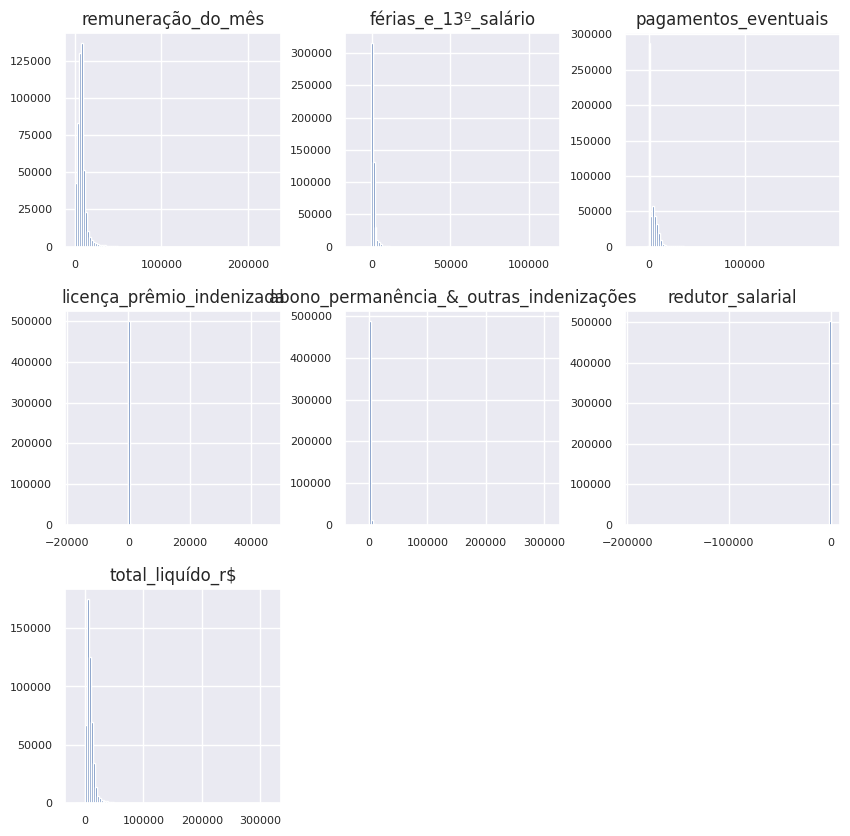

In [29]:
numeric_df.hist(figsize=(10, 10), bins=100, xlabelsize=8, ylabelsize=8)

2.1. Gerando histogramas utilizando a Matplotlib

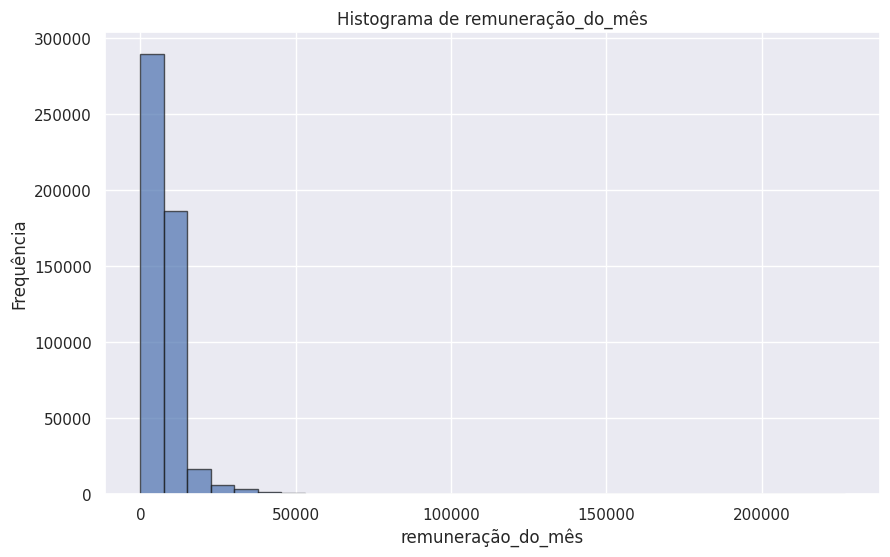

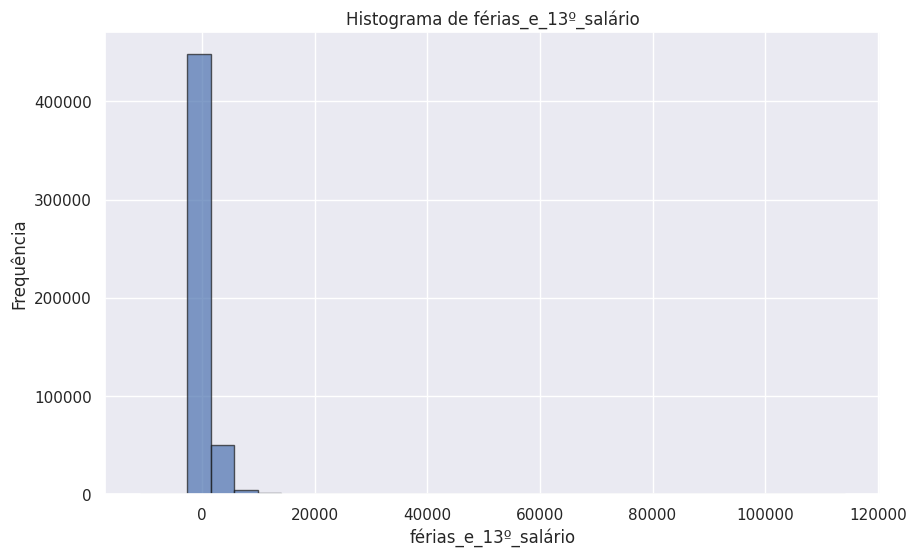

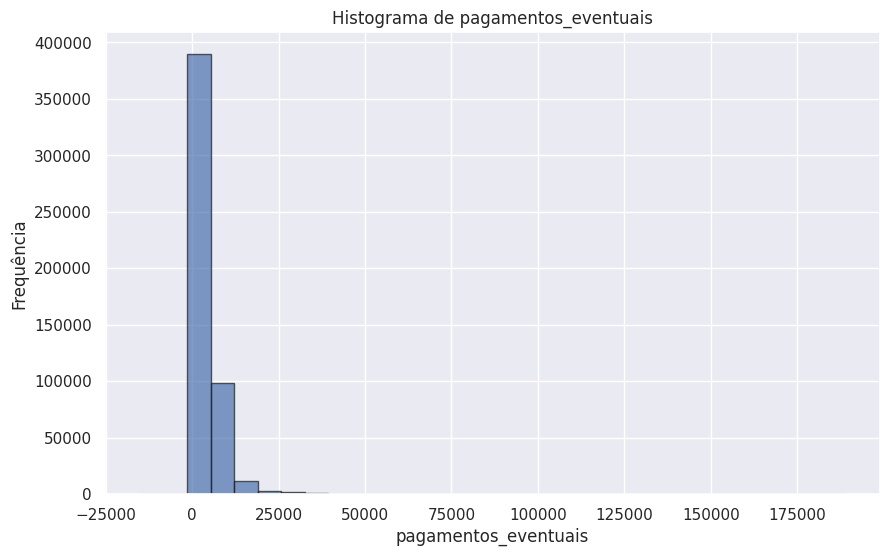

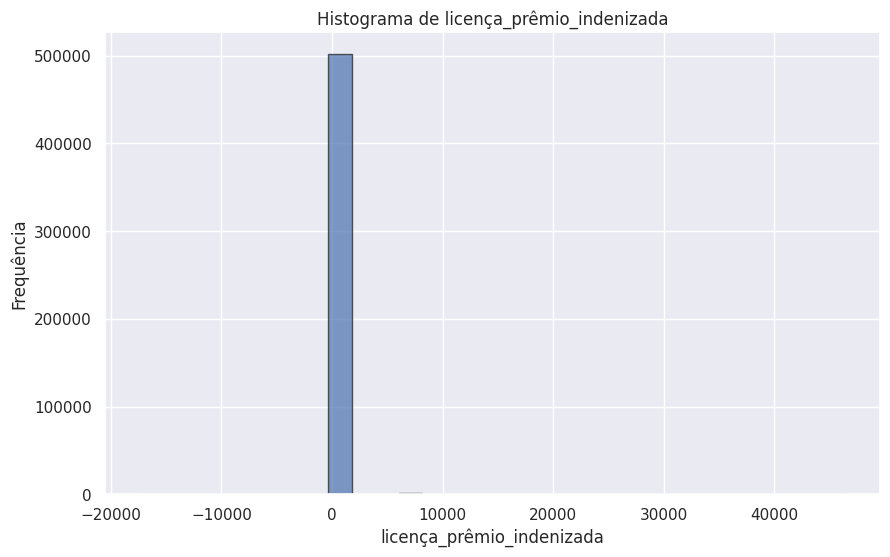

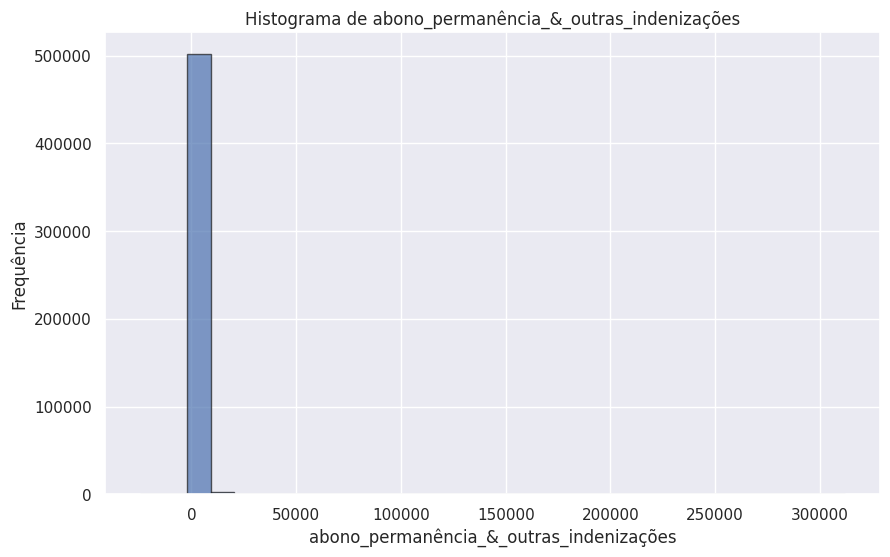

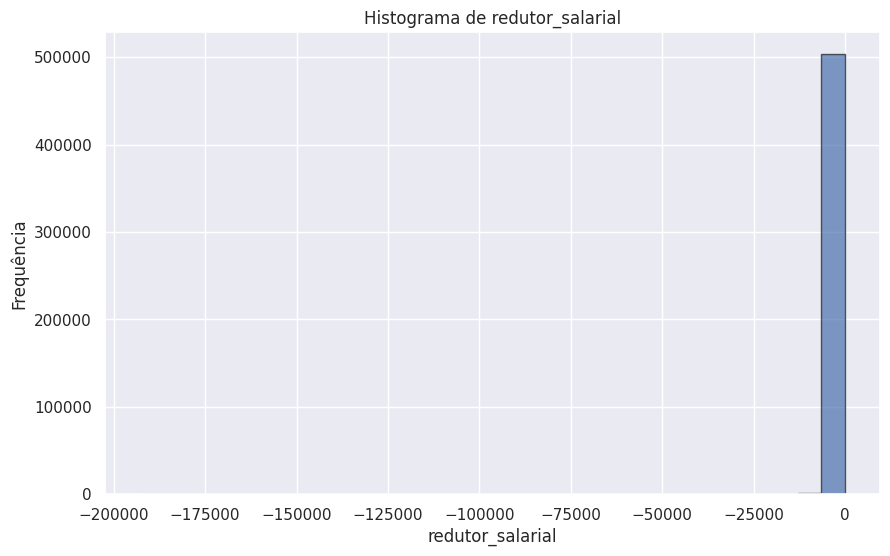

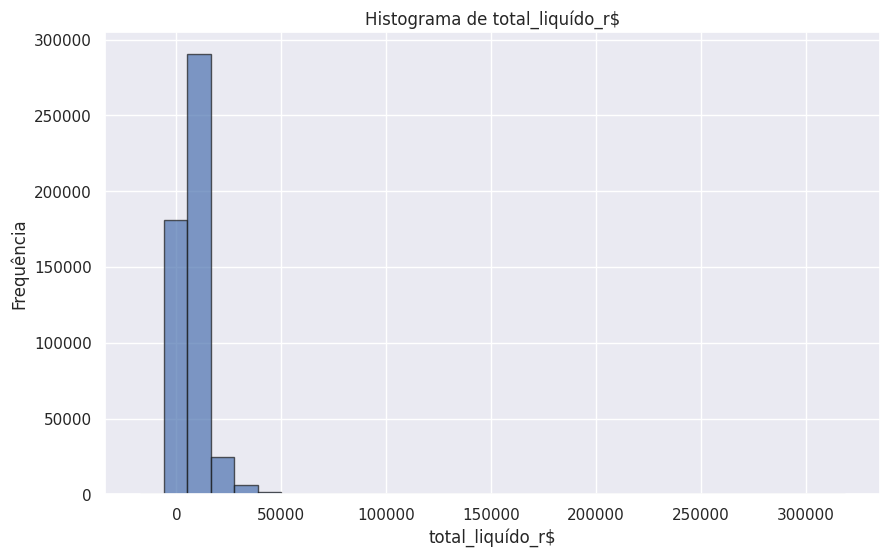

In [30]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar histogramas para cada coluna numérica
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(numeric_df[column].dropna(), bins=30, edgecolor='k', alpha=0.7)
    plt.title(f'Histograma de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')
    plt.grid(True)
    plt.show()

Gerando histogramas utilizando a Seaborn

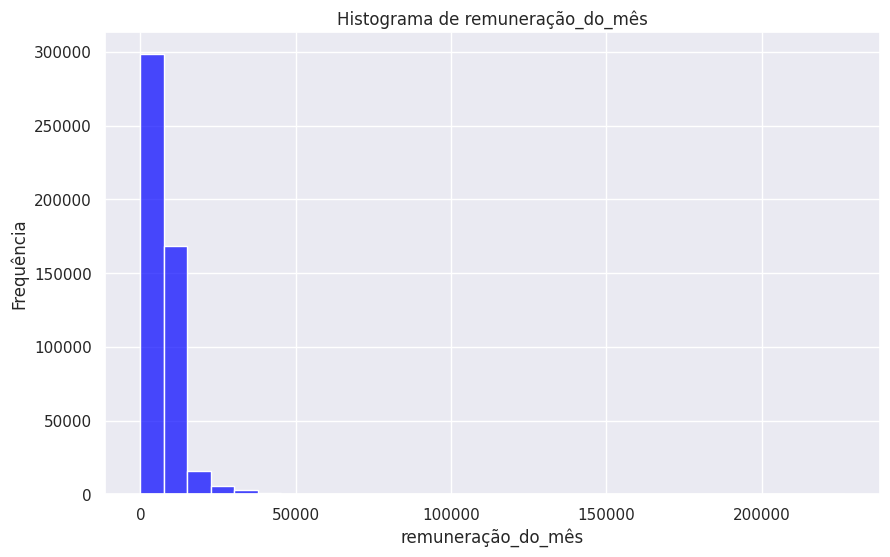

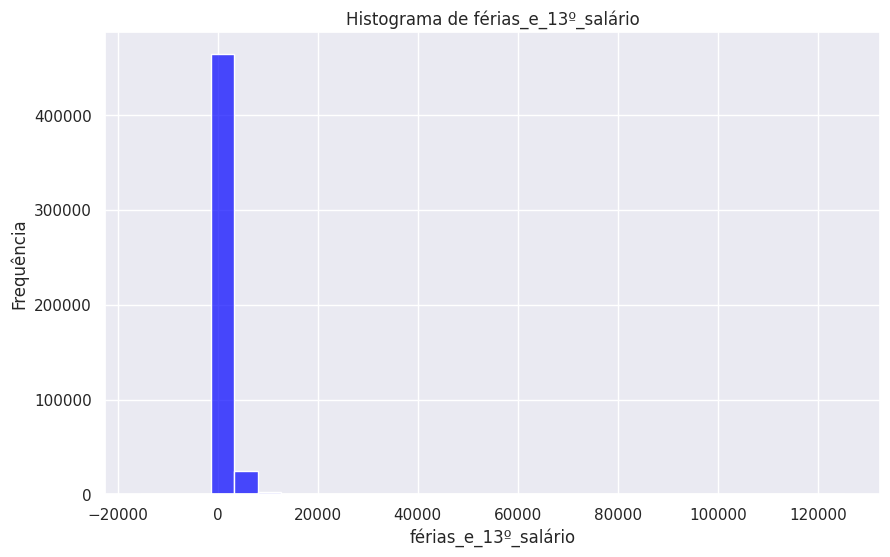

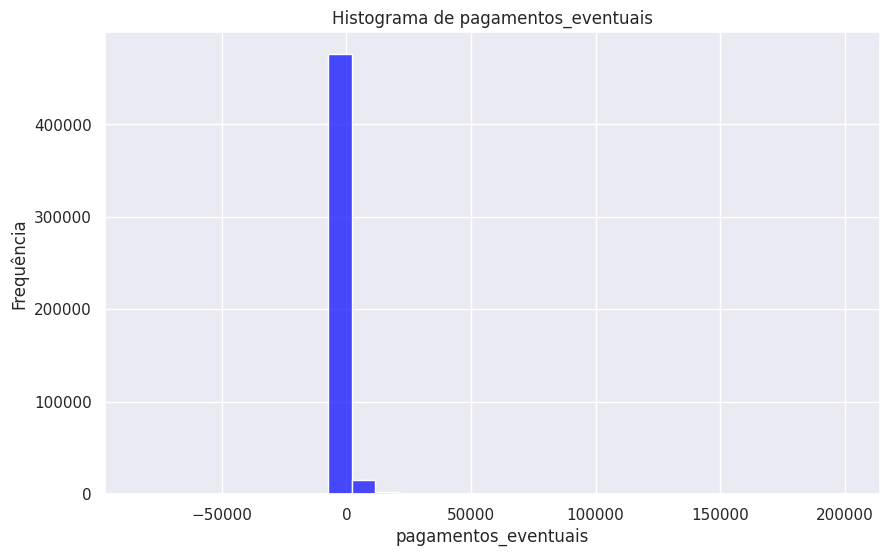

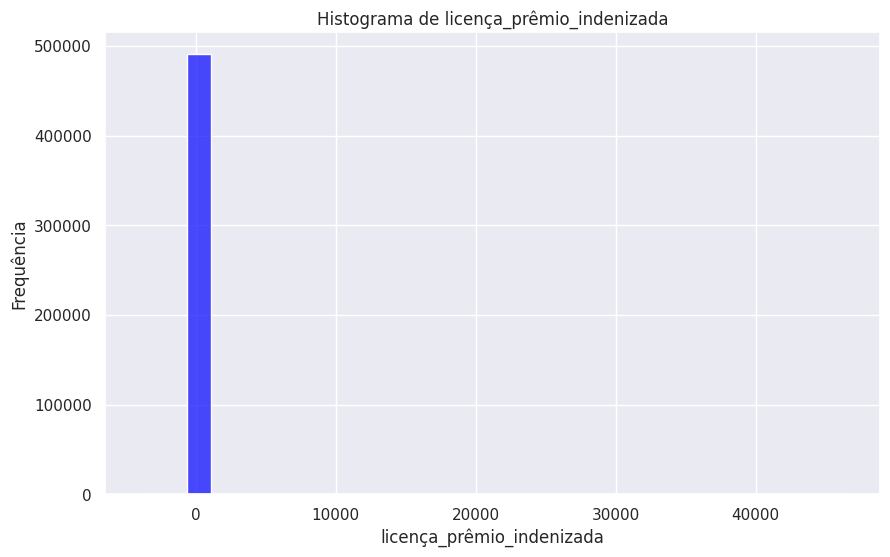

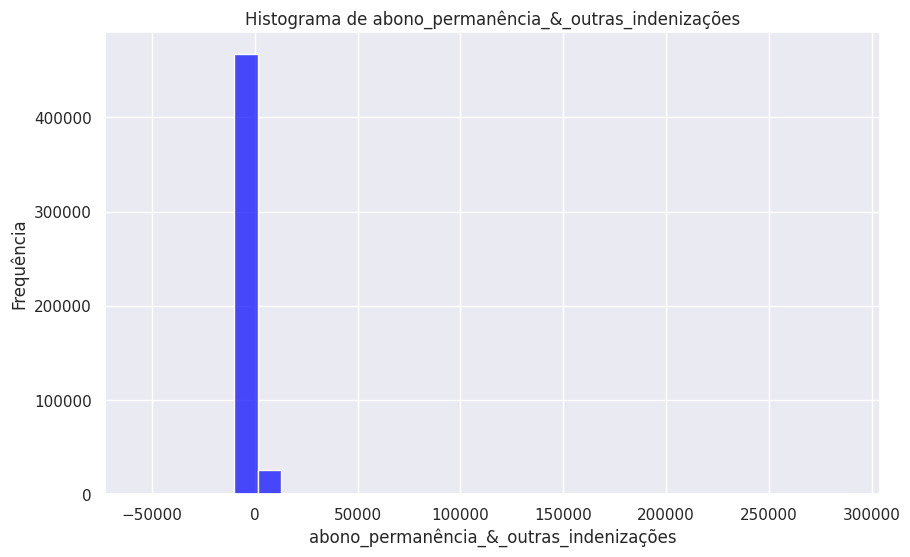

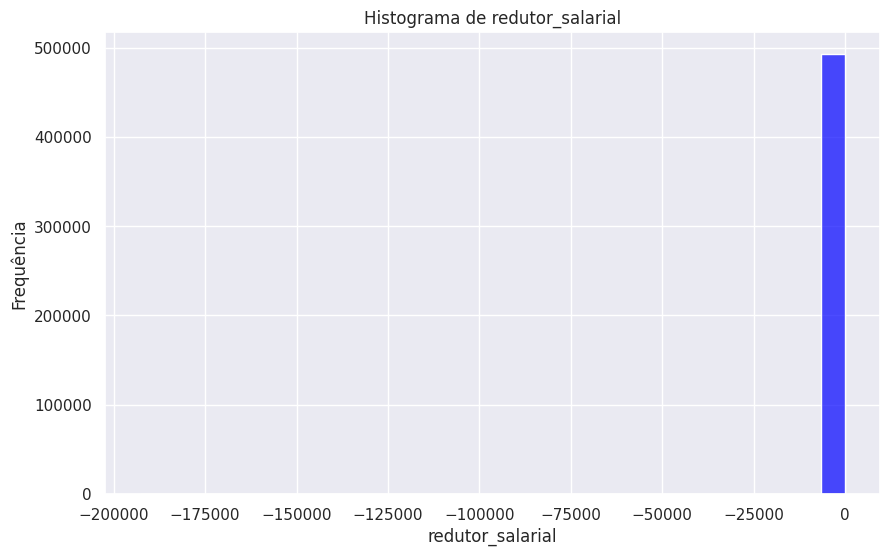

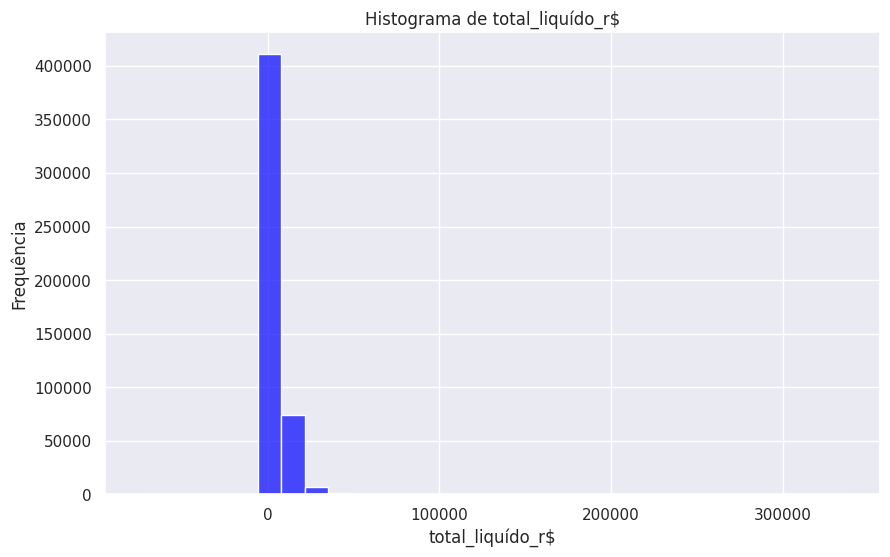

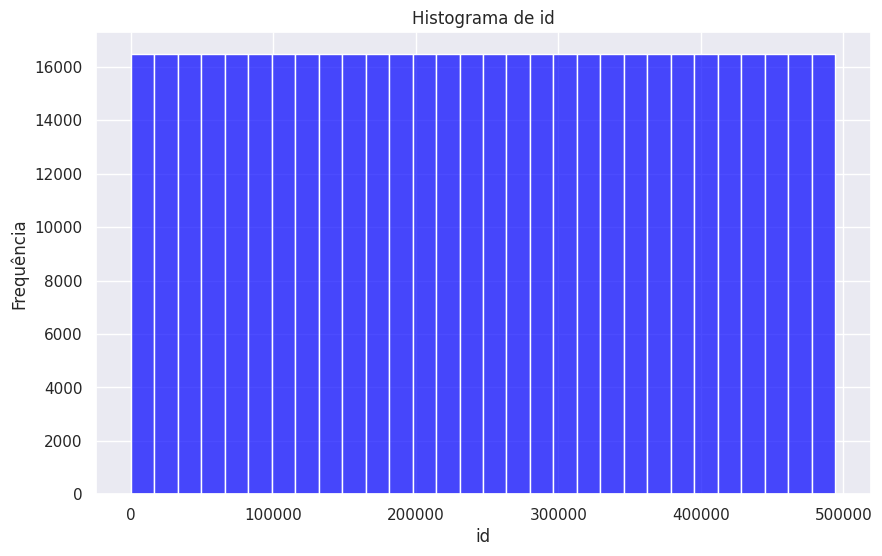

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar histogramas para cada coluna numérica usando seaborn
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(numeric_df[column].dropna(), bins=30, kde=False, color='blue', alpha=0.7)
    plt.title(f'Histograma de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')
    plt.grid(True)
    plt.show()

**Explicação:**
- plt.hist(): Cria um histograma básico usando matplotlib. O parâmetro bins define o número de intervalos no histograma, e edgecolor define a cor da borda dos bins.
- sns.histplot(): Cria um histograma usando seaborn, que também pode incluir uma estimativa da densidade de kernel (kde=True) se você desejar. O parâmetro color define a cor dos bins.
- O parâmetro alpha em visualizações como histogramas e gráficos de dispersão controla a transparência das barras ou pontos. O valor de alpha varia de 0 a 1, onde:
alpha = 0: Totalmente transparente.
alpha = 1: Totalmente opaco (sem transparência).

Ambos os métodos permitem visualizar a distribuição das variáveis numéricas no seu DataFrame. Ajuste o número de bins e outras opções conforme necessário para obter a visualização desejada.

**Observando em uma linha**

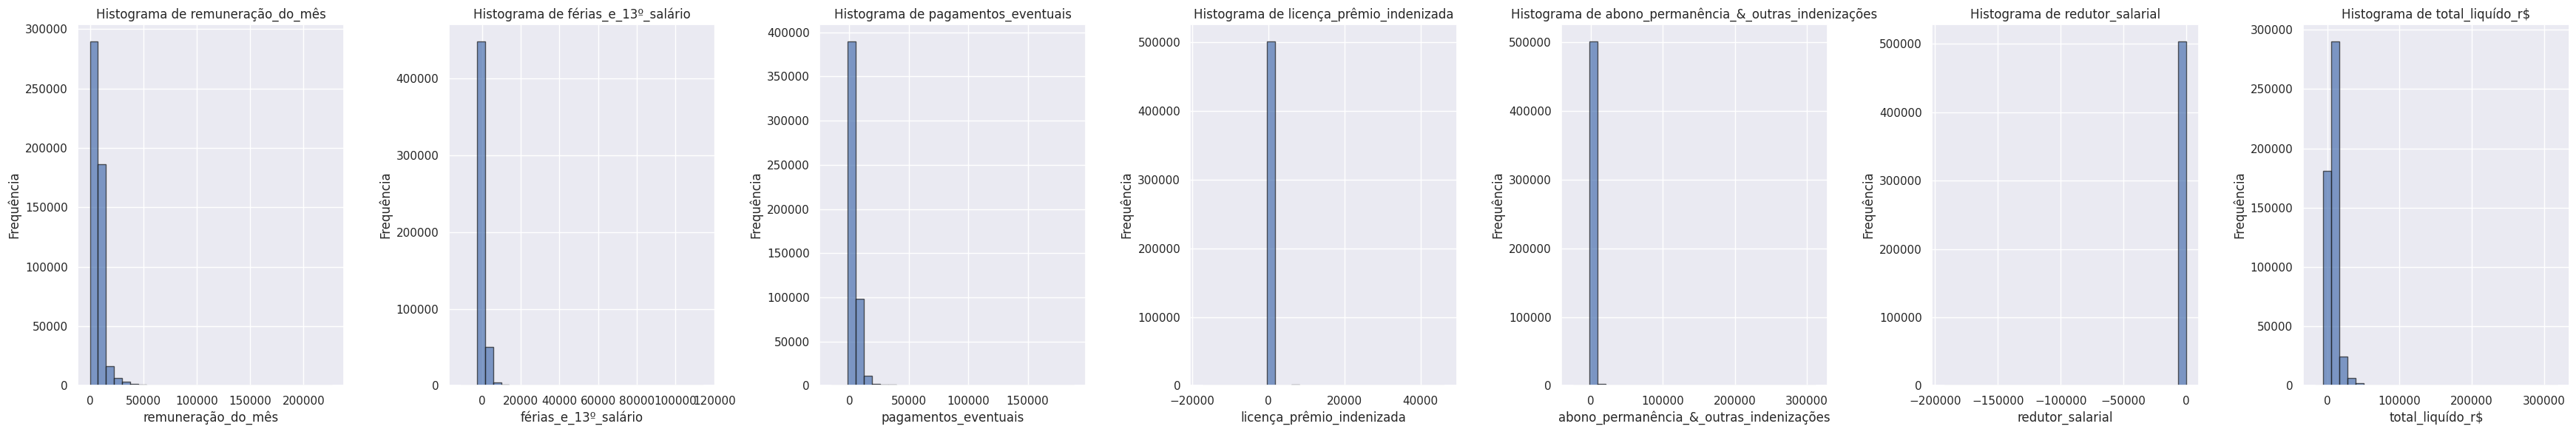

In [31]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar histogramas para cada coluna numérica
for ax, column in zip(axes, numeric_df.columns):
    ax.hist(numeric_df[column].dropna(), bins=30, edgecolor='k', alpha=0.7)
    ax.set_title(f'Histograma de {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequência')
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

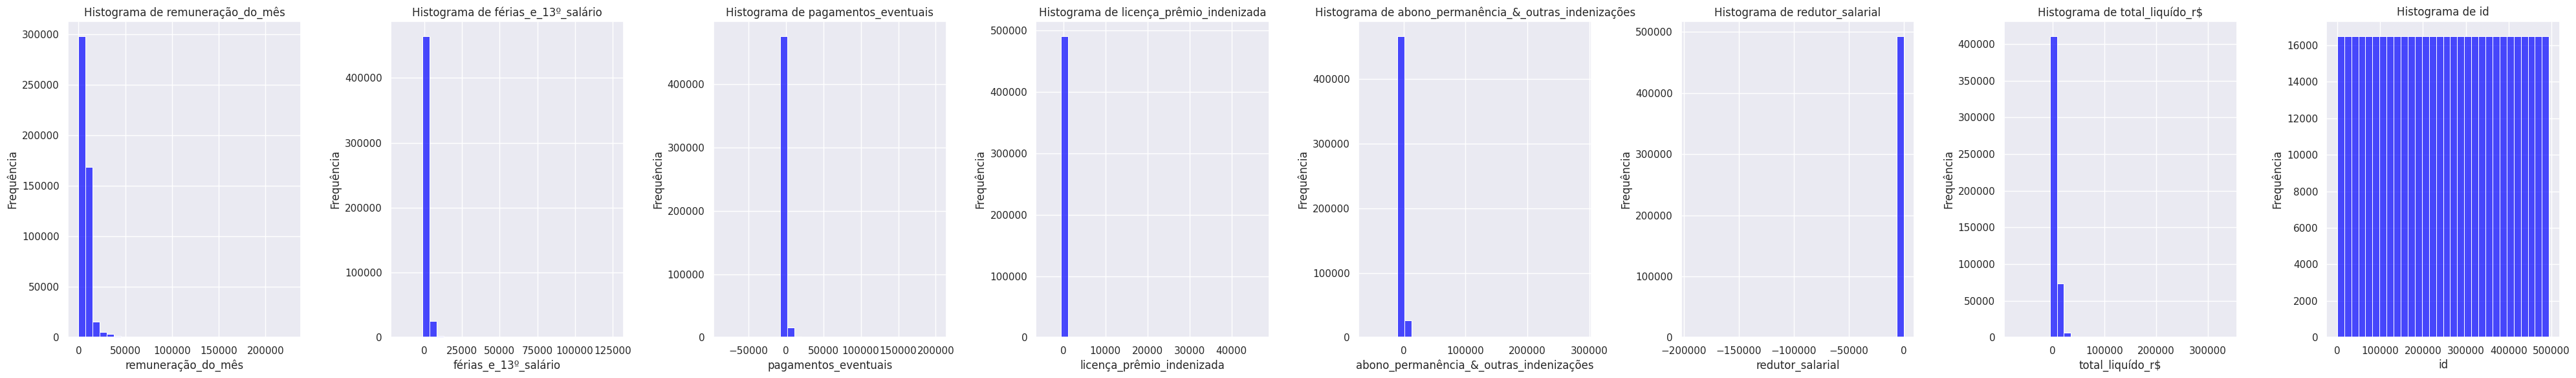

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar histogramas para cada coluna numérica usando seaborn
for ax, column in zip(axes, numeric_df.columns):
    sns.histplot(numeric_df[column].dropna(), bins=30, kde=False, ax=ax, color='blue', alpha=0.7)
    ax.set_title(f'Histograma de {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequência')
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

# **3. Boxplots**

**Boxplots com Matplotlib**

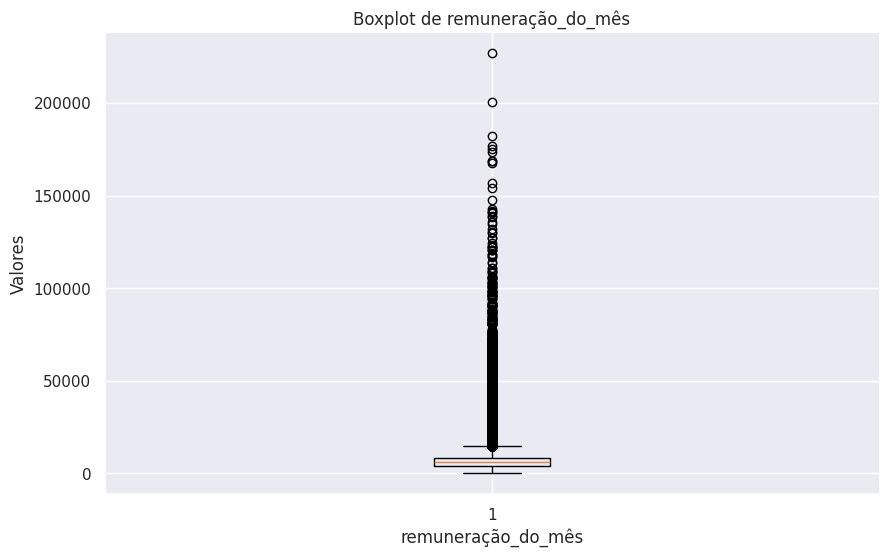

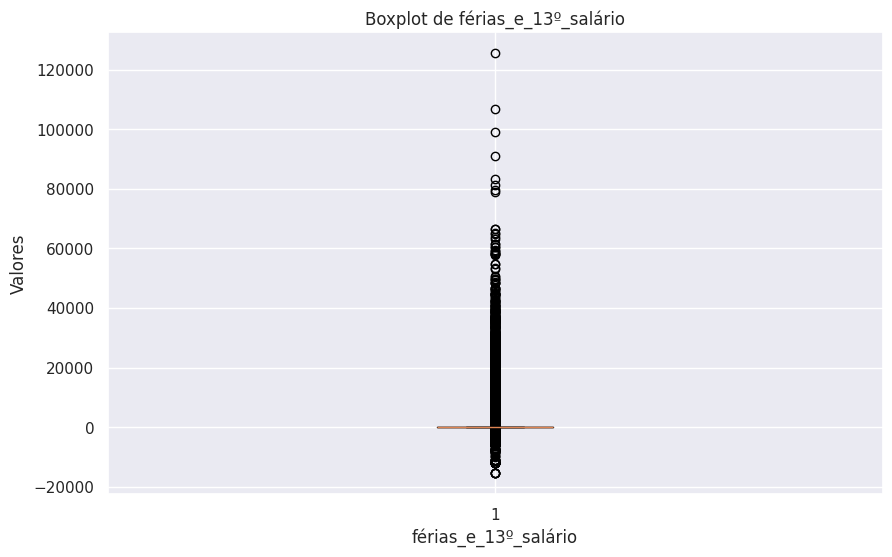

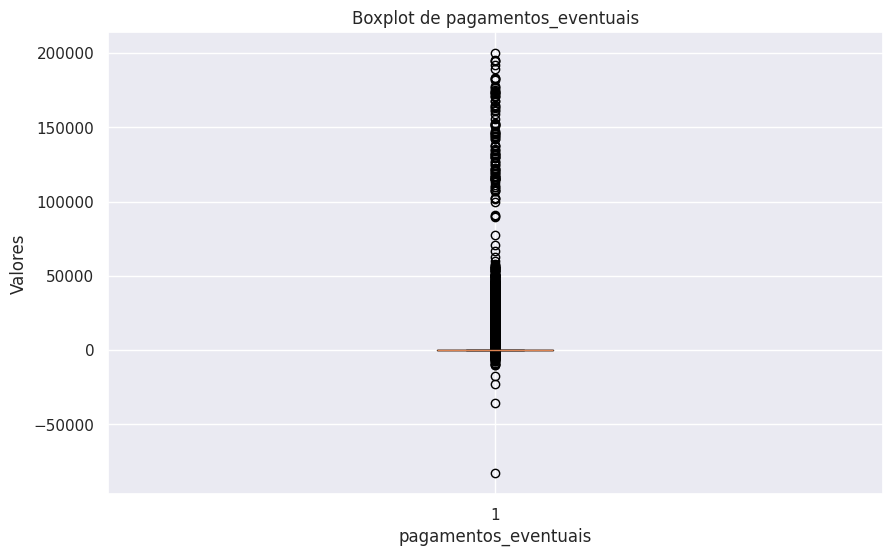

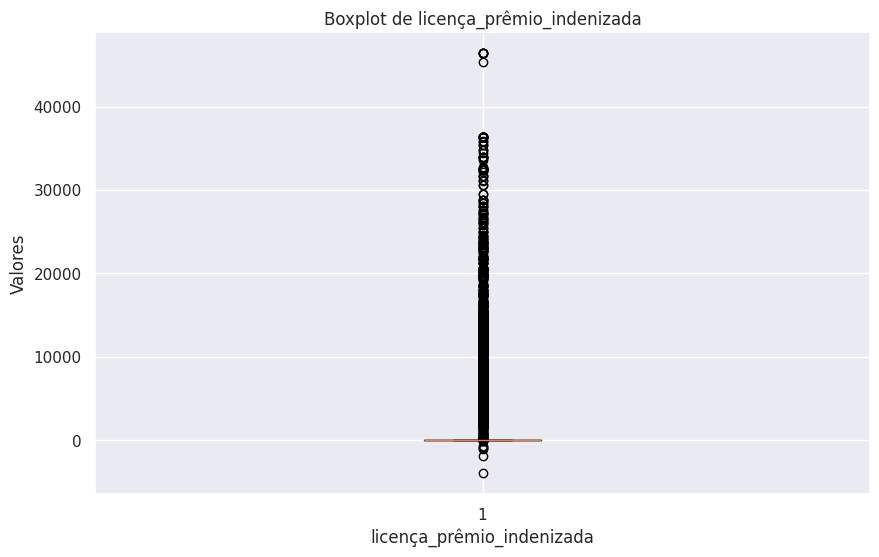

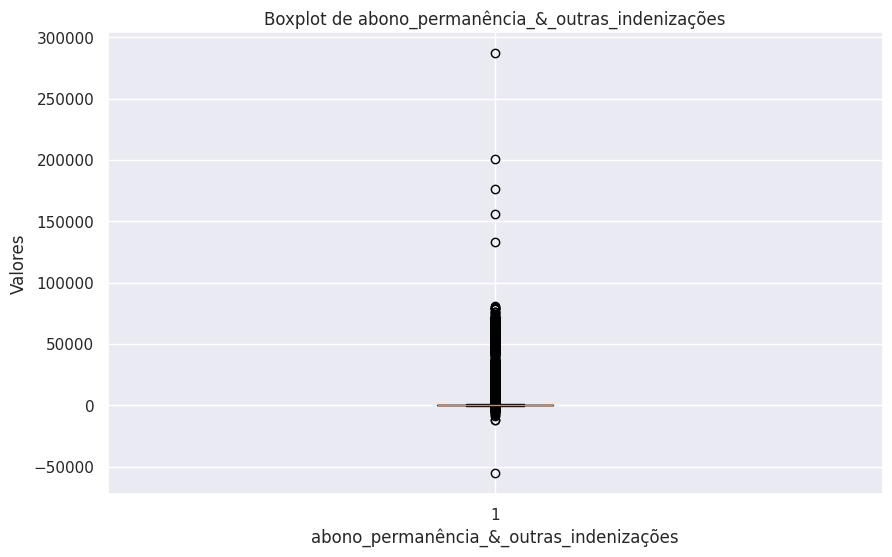

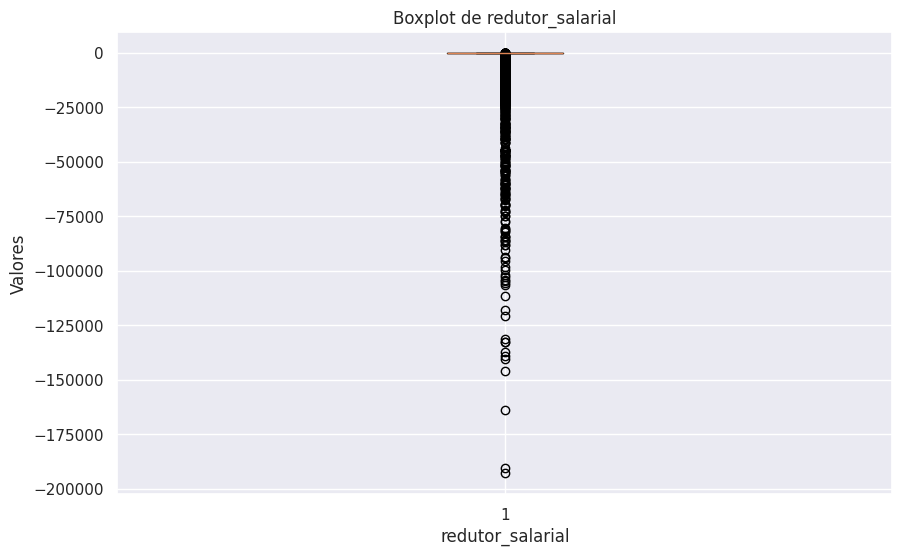

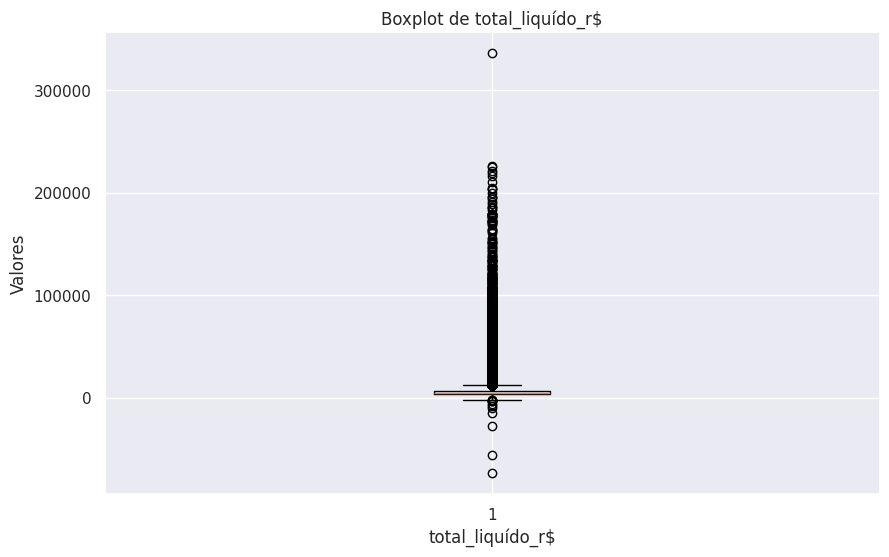

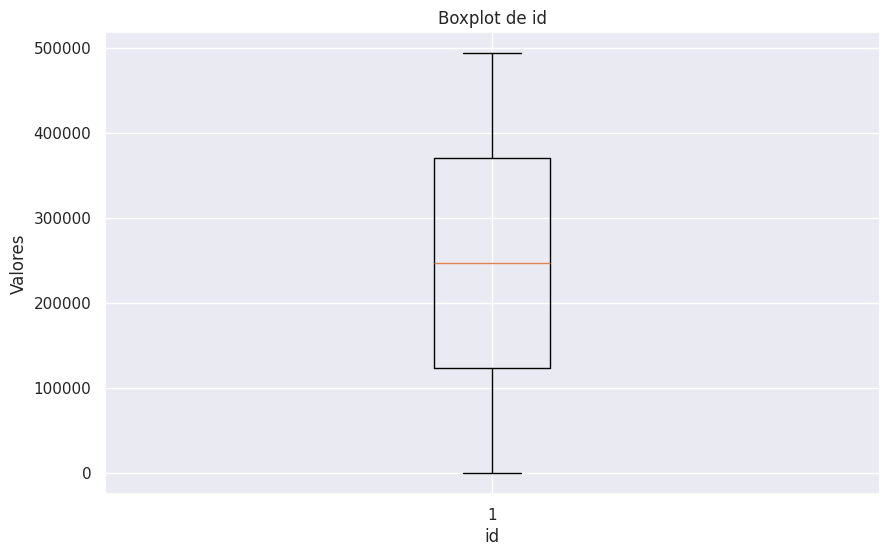

In [ ]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar boxplots para cada coluna numérica
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    plt.boxplot(numeric_df[column].dropna())
    plt.title(f'Boxplot de {column}')
    plt.xlabel(column)
    plt.ylabel('Valores')
    plt.grid(True)
    plt.show()

**Boxplots com Seaborn**

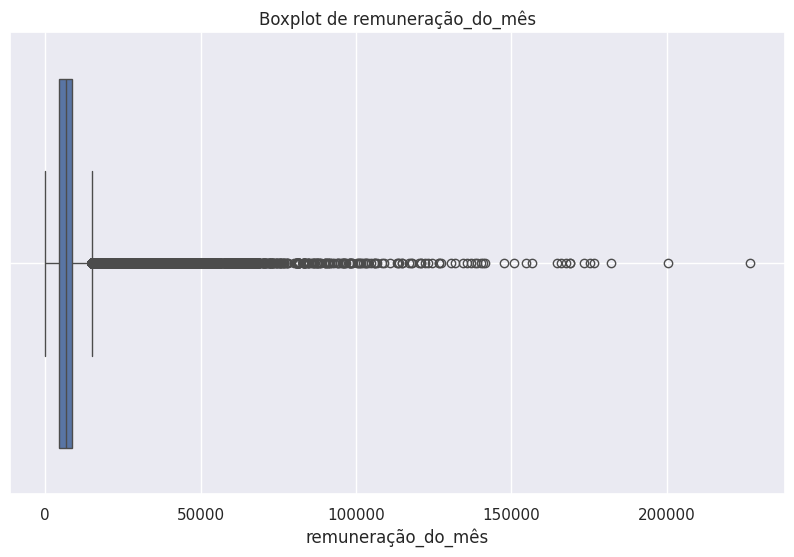

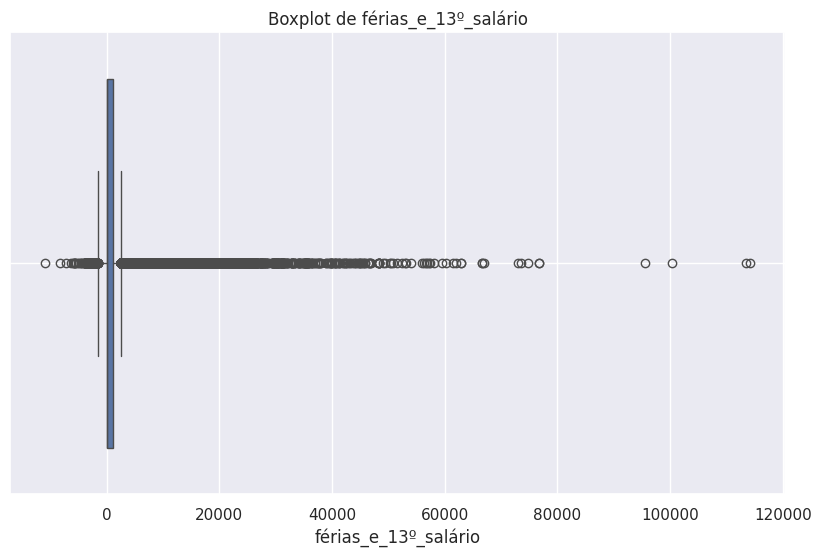

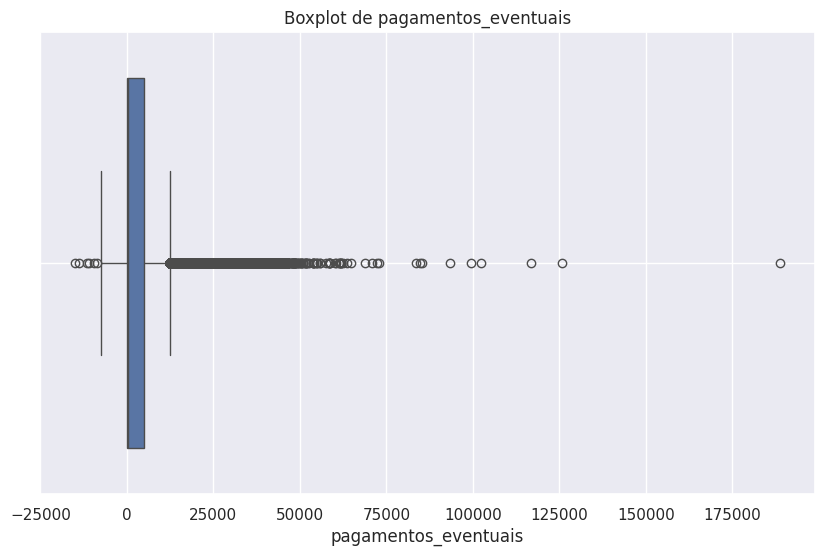

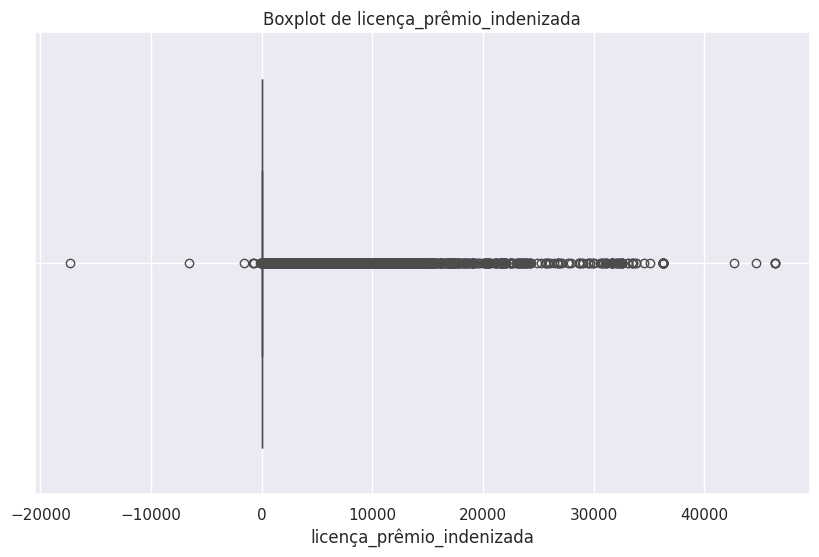

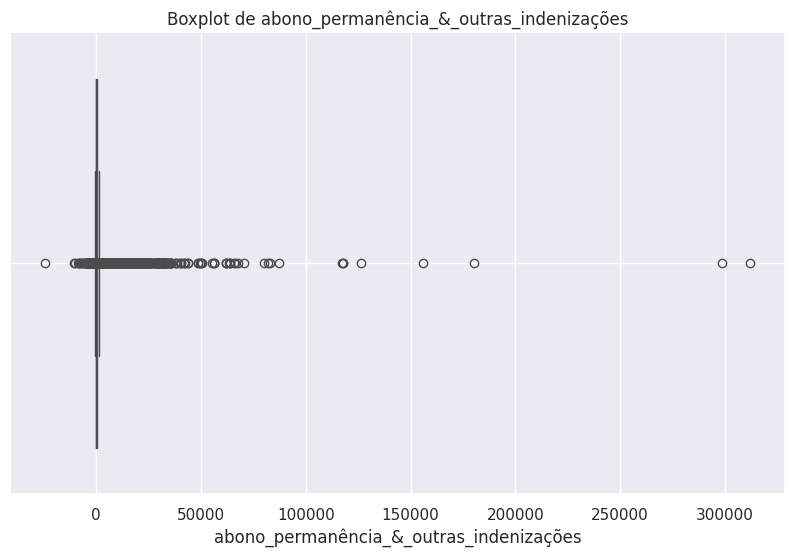

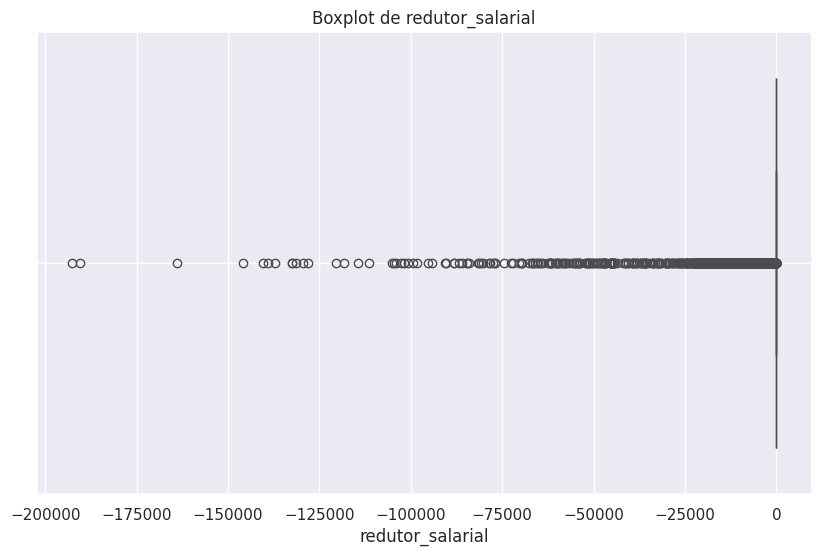

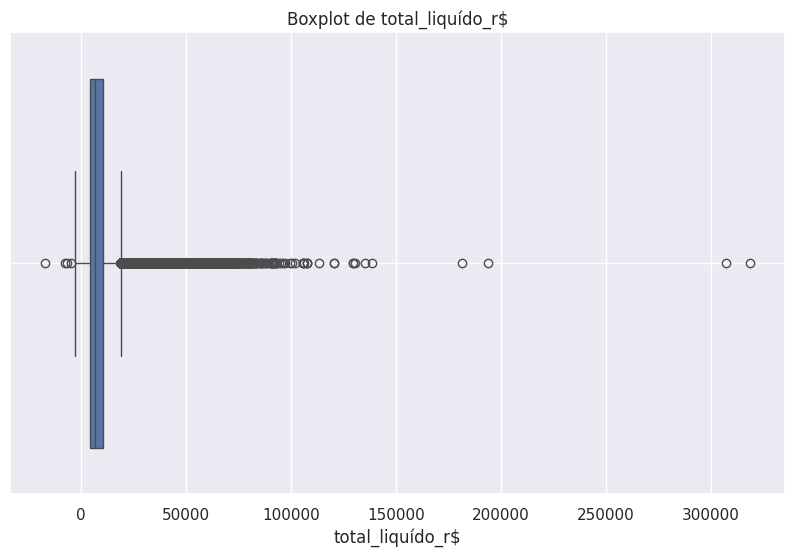

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Gerar boxplots para cada coluna numérica usando seaborn
for column in numeric_df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=numeric_df[column])
    plt.title(f'Boxplot de {column}')
    plt.xlabel(column)
    plt.grid(True)
    plt.show()

**Explicação:**
- plt.boxplot(): Cria um boxplot básico usando matplotlib. O boxplot exibe a mediana, os quartis e possíveis outliers dos dados.
- sns.boxplot(): Cria um boxplot usando seaborn, que oferece uma estética melhor e permite a inclusão de outras variáveis para comparação, se desejado.

Personalização Adicional
- plt.boxplot(): Permite várias personalizações, como adicionar notches (entrecortes) no boxplot para mostrar intervalos de confiança.
- sns.boxplot(): Permite incluir a estética da visualização e pode combinar facilmente com outras variáveis ou facetas.

Esses métodos permitirão visualizar a distribuição, a mediana, e os possíveis outliers para cada variável numérica no seu DataFrame.

**Observando em linha:**

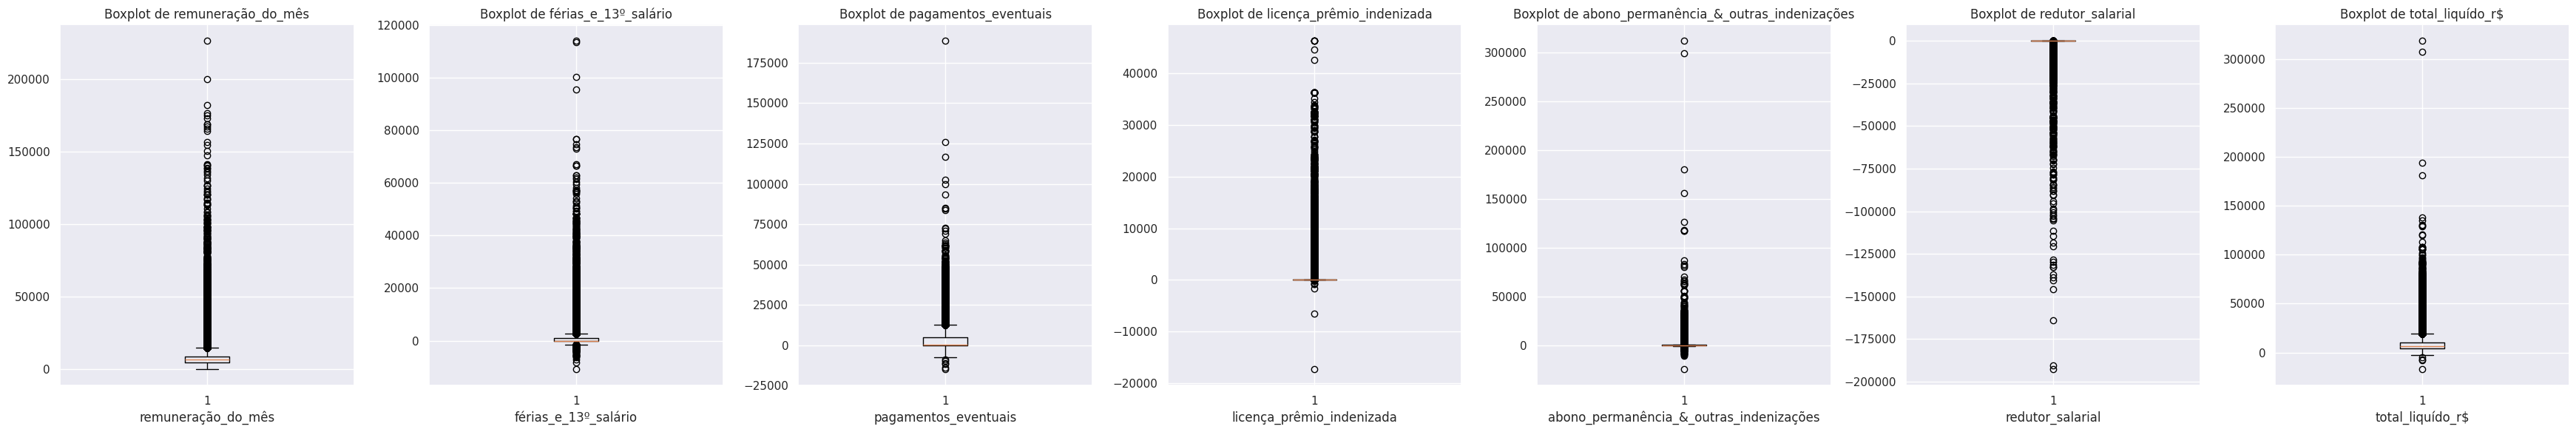

In [33]:
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar boxplots para cada coluna numérica
for ax, column in zip(axes, numeric_df.columns):
    ax.boxplot(numeric_df[column].dropna())
    ax.set_title(f'Boxplot de {column}')
    ax.set_xlabel(column)
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

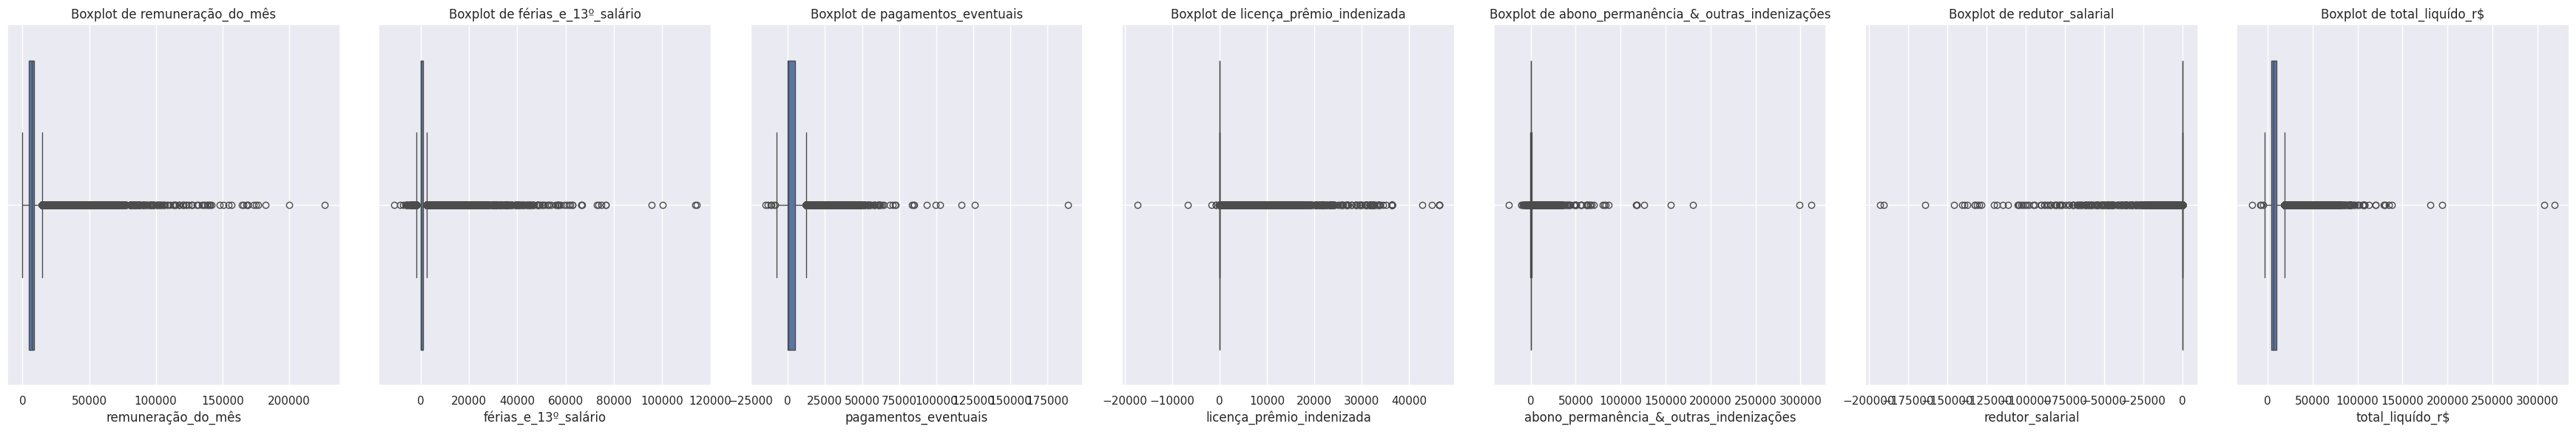

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrando apenas colunas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Definindo o número de subplots com base no número de colunas numéricas
num_vars = len(numeric_df.columns)
fig, axes = plt.subplots(1, num_vars, figsize=(5 * num_vars, 6))  # Ajuste o tamanho conforme necessário

# Gerar boxplots para cada coluna numérica usando seaborn
for ax, column in zip(axes, numeric_df.columns):
    sns.boxplot(x=numeric_df[column], ax=ax)
    ax.set_title(f'Boxplot de {column}')
    ax.set_xlabel(column)
    ax.grid(True)

# Ajustar o layout
plt.tight_layout()
plt.show()

# **4. Discussão**

O que está acontecendo aqui?
Vamos ver:
 - O que acontece com esses salários negativos
 - O que acontece com os salários gigantes

# 4.1. Salários líquidos negativos

Isso deve ser resultado de redutor salarial, não acham?

Ganhou a mais, agora desconta.

In [35]:
#Vamos ver os salários liquídos em relação ao redutor salarial
df[['total_liquído_r$', 'redutor_salarial']].sort_values(by='total_liquído_r$').head(10)

,total_liquído_r$,redutor_salarial
3233,-17162.96,0.0
253443,-7898.29,0.0
146408,-6945.88,0.0
425812,-4707.84,0.0
488532,-2892.43,0.0
217725,-2619.44,0.0
336933,-2373.09,0.0
358775,-2346.16,0.0
278925,-2111.35,0.0
382224,-1964.01,0.0


De onde vieram esses salários negativos?

In [36]:
cols = [
    'remuneração_do_mês',
    'férias_e_13º_salário',
    'pagamentos_eventuais',
    'licença_prêmio_indenizada',
    'abono_permanência_&_outras_indenizações',
    'redutor_salarial',
    'total_liquído_r$'
]

df.loc[
    df['total_liquído_r$'] < 0,
    cols
].head(10)

,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$
2887,0.00,0.00,-1137.33,0.0,0.00,0.0,-714.66
3233,0.00,-4979.70,-14939.13,0.0,0.00,0.0,-17162.96
24131,667.79,463.75,-1341.64,0.0,104.25,0.0,-1471.56
34529,540.48,0.00,2090.56,0.0,0.00,0.0,-1346.11
45177,278.25,0.00,-2094.11,0.0,-20.21,0.0,-1584.82
54285,445.20,166.95,-1600.02,0.0,0.00,0.0,-816.11
58900,1389.96,0.00,1341.56,0.0,0.00,0.0,-1262.00
138007,0.00,0.00,108.70,0.0,11.96,0.0,-155.50
142230,388.47,0.00,2860.25,0.0,0.00,0.0,-974.78
146408,0.00,0.00,3273.08,0.0,-3339.87,0.0,-6945.88


Parece que encontramos, coluna pagamentos_eventuais.

In [38]:
#Vamos ver os salários liquídos em relação ao redutor salarial
df[['total_liquído_r$', 'pagamentos_eventuais']].sort_values(by='total_liquído_r$').head(10)

,total_liquído_r$,pagamentos_eventuais
3233,-17162.96,-14939.13
253443,-7898.29,-11054.28
146408,-6945.88,3273.08
425812,-4707.84,979.46
488532,-2892.43,-6970.20
217725,-2619.44,0.00
336933,-2373.09,1727.69
358775,-2346.16,0.00
278925,-2111.35,0.00
382224,-1964.01,123.98


Isso é raro… ou é frequente?

In [39]:
(df['total_liquído_r$'] < 0).sum()

np.int64(40)

Vamos olhar a estatística descritiva desses 42 sujeitos:

In [43]:
df[df['total_liquído_r$'] < 0]['total_liquído_r$'].describe()

,total_liquído_r$
count,40.000000
mean,-1876.216750
std,3002.388668
min,-17162.960000
25%,-1958.310000
50%,-1118.390000
75%,-341.347500
max,-68.090000


**Já imaginou isso indo para algum modelo??**

Quais situações podem gerar salário líquido negativo em folha de pagamento pública?
- Pergunte a LLM

Solução?

In [41]:
#Eu só separaria os negativos por enquanto, até entender o que é isso
df_negativos = df[df['total_liquído_r$'] < 0]
df_positivos = df[df['total_liquído_r$'] >= 0]

Sobre a LLM aqui vai a resposta da minha:
- Veja a associação das variáveis

In [42]:
df[['total_liquído_r$', 'pagamentos_eventuais']].corr()

,total_liquído_r$,pagamentos_eventuais
total_liquído_r$,1.000000,0.635792
pagamentos_eventuais,0.635792,1.000000


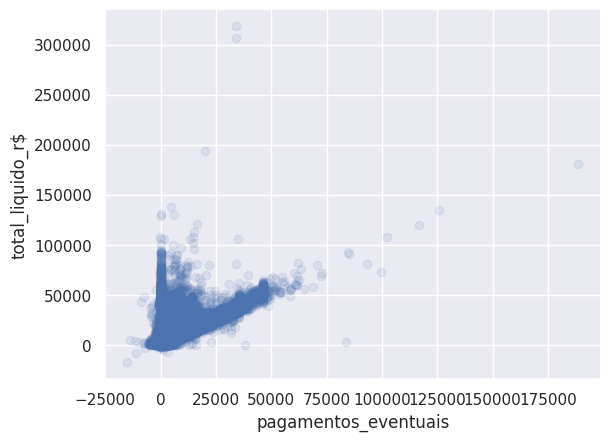

In [44]:
import matplotlib.pyplot as plt

plt.scatter(df['pagamentos_eventuais'], df['total_liquído_r$'], alpha=0.1)
plt.xlabel('pagamentos_eventuais')
plt.ylabel('total_liquido_r$')
plt.show()

**O que descobrimos?**
- O salário líquido é altamente sensível a pagamentos_eventuais
- Se eu ignorar essa variável minha análise fica correta? (não)
- Variáveis com nome ‘eventual’
podem ser as mais importantes do dataset
- Nem tudo que parece bônus… é bônus

**Temos como ter certeza da causa disso?**

HIPÓTESES MAIS PROVÁVEIS
1. Estorno de pagamento anterior
pagaram errado
estão descontando agora
2. Ajuste administrativo
correção de folha
decisão judicial
3. Lançamento acumulado
múltiplos ajustes em um mês

# 4.2. Salários liquídos gigantes

In [45]:
#Vamos ver quem são, estamos só filtrando planilha aqui (só que uma de meio milhão de linhas)
df_top = df.sort_values(by='total_liquído_r$', ascending=False).head(10)
df_top

,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$
96132,CLOVIS PAES DE AZEVEDO NETO,AUDITOR FISCAL DA RECEITA EST,SECRET. FAZENDA PLANEJAMENTO,55058.82,0.00,34276.22,0.0,311877.41,-18757.29,318486.16
67214,CACILDA PEIXOTO,AUDITOR FISCAL DA RECEITA EST,SECRET. FAZENDA PLANEJAMENTO,48442.60,0.00,34046.86,0.0,298784.66,-13118.47,307114.15
91062,CLAUDIO ALVARENGA DE MELO,ESPECIALISTA AGROPECUARIO VI,SECR.AGRICULTURA ABASTECIMENTO,20496.15,0.00,20081.20,0.0,180072.14,0.00,193611.20
320618,MARCOS ROBERTO PEREIRA,1SGT PM,POLICIA MILITAR SAO PAULO,21965.77,6703.86,188714.79,0.0,653.14,0.00,181212.16
333189,MARIA LAIS GUZZO LEAO,ENGENHEIRO II,CETESB-CIA.AMBIENTAL EST.S.P.,27392.97,8991.85,4608.61,0.0,126316.98,0.00,138307.43
166589,FABIOLA C R S TCHAKERIAN,CCESP 1.05-CHEFE DE SECAO,SECRETARIA DA EDUCACAO,11541.43,6911.67,125890.58,0.0,0.00,0.00,135113.20
237833,JORGE SAKOTANI,ENGENHEIRO III,CETESB-CIA.AMBIENTAL EST.S.P.,18599.85,6497.98,0.00,0.0,117790.83,0.00,130489.04
239930,JOSE CARLOS DE MOURA XAVIER,ENGENHEIRO II,CETESB-CIA.AMBIENTAL EST.S.P.,7822.58,7319.41,5873.59,0.0,117118.83,0.00,129640.97
198385,GUERINO COLLA,AN ADM III,CETESB-CIA.AMBIENTAL EST.S.P.,19358.98,3305.88,0.00,0.0,117693.67,0.00,129232.68
29649,ANA CLAUDIA FERREIRA DE CASTIL,ASSESSOR TECNICO IV,COMP.METROPOLITANO S.P.-METRO,39558.52,114145.54,16254.75,0.0,0.00,0.00,120456.61


E ai LLM? O que isso significa?

**Esses casos têm padrão muito interessante:**
- O driver principal NÃO é salário base
- remuneração_do_mês → ~8k a 36k
- total_liquido → 200k+

**impossível vir do salário base**

- Quem está dominando?

👉 pagamentos_eventuais
👉 indenizações

**CONCLUSÃO PRINCIPAL**

🔥 Esses valores NÃO são salários mensais
🔥 São eventos extraordinários acumulados

**Grupo dominante:**

CIRURGIÃO DENTISTA – Secretaria da Saúde

**Por que esse grupo específico aparece tanto?**

🧠 HIPÓTESES FORTES
1. 🔥 Pagamentos retroativos
acúmulo de meses/anos
2. 🔥 Ações judiciais
decisões liberando valores
3. 🔥 Indenizações acumuladas
férias
benefícios
4. 🔥 Mudança de regime/contrato

In [ ]:
#Vamos ver quem são, estamos só filtrando planilha aqui (só que uma de meio milhão de linhas)
df_top = df.sort_values(by='total_liquído_r$', ascending=False).head(10)
df_top

In [46]:
df_top['cargo'].value_counts()

,count
cargo,
AUDITOR FISCAL DA RECEITA EST,2
ENGENHEIRO II,2
ESPECIALISTA AGROPECUARIO VI,1
1SGT PM,1
CCESP 1.05-CHEFE DE SECAO,1
ENGENHEIRO III,1
AN ADM III,1
ASSESSOR TECNICO IV,1


In [52]:
df.groupby('cargo')['remuneração_do_mês'].mean().sort_values(ascending=False).head(10)

,remuneração_do_mês
cargo,
PROCURADOR DE AUTARQUIA IV,73368.190000
PROCURADOR AUTARQ. ASSISTENTE,71386.050000
PROCURADOR DE AUTARQUIA I,70957.580000
DIRETOR JOR ESPORTIV,70586.320000
PROCURADOR DE AUTARQUIA V,68112.182000
ENGENHEIRO VI,67468.626471
PROCURADOR DE AUTARQUIA III,66097.486667
PROCURADOR ESTADO CORREG.GERAL,64429.880000
PROCURADOR GERAL DO ESTADO,64209.550000


In [48]:
(df['pagamentos_eventuais'] > 100000).sum()

np.int64(4)

MOMENTO LLM

Quais situações explicam pagamentos eventuais muito altos em servidores públicos?

# **5. Mergulho profundo**

Nós vamos agora tentar entender como as colunas contribuem para o total líquido

**1 — Criar as proporções**

In [49]:
componentes = [
    'remuneração_do_mês',
    'férias_e_13º_salário',
    'pagamentos_eventuais',
    'licença_prêmio_indenizada',
    'abono_permanência_&_outras_indenizações',
    'redutor_salarial'
]

for col in componentes:
    df[f'perc_{col}'] = df[col] / df['total_liquído_r$']

In [50]:
#Pode ter zeros, isso aqui evita divisão por zero
for col in componentes:
    df[f'perc_{col}'] = df[col] / df['total_liquído_r$'].replace(0, None)

**2 — Analisando salários mais altos**

Aqui estamos vendo proporcionalmente os salários extremos, veja que interessante:

In [51]:
df_top = df.sort_values(by='total_liquído_r$', ascending=False).head(10)

cols_perc = [f'perc_{col}' for col in componentes]

df_top[cols_perc]

,perc_remuneração_do_mês,perc_férias_e_13º_salário,perc_pagamentos_eventuais,perc_licença_prêmio_indenizada,perc_abono_permanência_&_outras_indenizações,perc_redutor_salarial
96132,0.172877,0.0,0.107622,0.0,0.979249,-0.058895
67214,0.157735,0.0,0.110861,0.0,0.972878,-0.042715
91062,0.105862,0.0,0.103719,0.0,0.930071,0.0
320618,0.121216,0.036995,1.041402,0.0,0.003604,0.0
333189,0.198059,0.065013,0.033321,0.0,0.913306,0.0
166589,0.08542,0.051155,0.931742,0.0,0.0,0.0
237833,0.14254,0.049797,0.0,0.0,0.902688,0.0
239930,0.06034,0.056459,0.045307,0.0,0.903409,0.0
198385,0.149799,0.025581,0.0,0.0,0.910711,0.0
29649,0.328405,0.947607,0.134943,0.0,0.0,0.0


O que acha, conorda?
 - pagamentos_eventuais → dominante
 - abonos grandes
 - salário base pequeno proporcionalmente

**3 - Visão global**

In [ ]:
df[cols_perc].mean().sort_values(ascending=False)

,0
perc_remuneração_do_mês,4.854942
perc_férias_e_13º_salário,2.270561
perc_pagamentos_eventuais,0.332164
perc_abono_permanência_&_outras_indenizações,0.060782
perc_licença_prêmio_indenizada,0.003445
perc_redutor_salarial,-0.001882


**Esses valores não deveriam somar ~1?**
 - totais muito pequenos / negativos
 - proporções “explodindo”
 - efeito de divisão instável

Veja as proporções dos super salários:

In [ ]:
df_extremos = df[df['total_liquído_r$'] > 100000]

df_extremos[cols_perc].mean()

,0
perc_remuneração_do_mês,0.252894
perc_férias_e_13º_salário,0.12826
perc_pagamentos_eventuais,0.553564
perc_licença_prêmio_indenizada,0.019626
perc_abono_permanência_&_outras_indenizações,0.230575
perc_redutor_salarial,-0.042007


Veja que temos uma tendência diferente.


 - **Isso significa que não podemos analisar tudo junto?**

- **Estamos olhando um único fenômeno, ou vários fenômenos misturados?**

- **Se eu treinar um modelo com tudo junto…
ele aprende o quê?**

**TRADUÇÃO CONCEITUAL**

🔹 Dataset geral:
dominado por salário base
comportamento “normal”

🔹 Extremos:
dominados por eventos
comportamento “anômalo” (mas real)

Possível solução:
- Separar os eventos

In [ ]:
df_normal = df[df['pagamentos_eventuais'] < 10000]
df_evento = df[df['pagamentos_eventuais'] >= 10000]

Não esqueça que deixamos os negativos la atrás separados

# **6. Critérios de fracionamento usando estatística**

Nós vamo sutilizar tecnicoas de remoção de outliers para visualizar como seria o dataset sem esses extremos.

Essa é uma etapa comum na limpeza e pré-processamento de dados. Mas sempre cuidado, pois os extremos podem carregar informações importantes, como observamos nas etapas anteriores.

Existem várias maneiras de identificar e remover outliers, porém a existência de um outlier não necessáriamente indica que o dado precisa ser removido.

Atenção em cuidado na análise dos outliers antes de remove-los.

    Desvio Padrão
    Intervalo Interquartil (IQR)
    Boxplots - já utilizamos
   
Sempre busque analisar e visualizar os Outliers antes de remove-los, realize a análise variável por variável, e se for necessário, utilizando o dataframe completo.

# **6.1 Abordagem utilizando IQR**

**Removendo utilizando o Intervalo Interquartil (IQR)**

Uma abordagem que considerara dados que estão acima ou abaixo do IQR como outliers.

Explicação:
- Calcular Q1, Q3 e IQR: Calcula o primeiro quartil (Q1), o terceiro quartil (Q3) e o intervalo interquartil (IQR) para a coluna especificada.
- Definir Limite Superior:
Valores acima desse limite são considerados outliers superiores.
- Definir Limite Inferior:
Valores acima abaixo limite são considerados outliers inferiores.
- Filtrar o DataFrame: Filtra o DataFrame para manter apenas as linhas onde o valor na coluna especificada é menor ou igual ao limite superior.
- Depois salvamos os extremos e removemos do dataset

**6.1 Abordagem utilizando IQR - para outliers superiores ao IQR.**

In [53]:
def filter_above_iqr_for_column(df, column_name):
    # Calcular Q1, Q3 e IQR
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Limite superior
    upper_bound = Q3 + 1.5 * IQR

    # Filtrar valores acima do limite superior
    column_outliers = df[df[column_name] > upper_bound]

    return column_outliers

# Filtrar valores superiores ao IQR para a coluna 'XXXX'
outliers_up = filter_above_iqr_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("Valores superiores ao IQR na coluna 'total_liquído_r$':")
outliers_up

Valores superiores ao IQR na coluna 'total_liquído_r$':


,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$,perc_remuneração_do_mês,perc_férias_e_13º_salário,perc_pagamentos_eventuais,perc_licença_prêmio_indenizada,perc_abono_permanência_&_outras_indenizações,perc_redutor_salarial
20,ABDIAS BESSA FILHO,CABO PM,POLICIA MILITAR SAO PAULO,9851.00,3917.95,0.00,8621.56,614.72,0.00,19754.95,0.49866,0.198328,0.0,0.436425,0.031117,0.0
25,ABDIEL CESAR BRANCO,PROFESSOR EDUCACAO BASICA II,SECRETARIA DA EDUCACAO,14098.62,2382.89,13089.97,0.00,0.00,0.00,21187.79,0.665412,0.112465,0.617807,0.0,0.0,0.0
69,ABEL JOSE DA SILVA,PROFESSOR DE ENSINO MED E TEC,"CTRO.EST.ED.TEC.""P.SO"" CEETEPS",17815.15,0.00,28247.15,0.00,0.00,0.00,33580.66,0.530518,0.0,0.841173,0.0,0.0,0.0
85,ABEL ZORZETTO FILHO,ARQUITETO VI,SEC.MEIO AMB. INFRA.LOGIST.,120828.70,0.00,0.00,0.00,0.00,-84527.17,26462.52,4.566032,0.0,0.0,0.0,0.0,-3.194222
88,ABELARDO ALVES GOMES,DELEGADO POLICIA 1A CLASSE,SECRETARIA SEGURANCA PUBLICA,38203.39,3167.75,9397.72,0.00,883.66,0.00,30730.63,1.24317,0.103081,0.30581,0.0,0.028755,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504782,ZIQUEIDE VITA DA SILVA,DELEGADO POLICIA 1A CLASSE,SECRETARIA SEGURANCA PUBLICA,29688.35,0.00,4993.02,0.00,422.62,0.00,22024.77,1.347953,0.0,0.2267,0.0,0.019188,0.0
504835,ZULANGE ODILA DA SILVA GRILLO,PROFESSOR DE ENSINO MED E TEC,"CTRO.EST.ED.TEC.""P.SO"" CEETEPS",15824.72,0.00,27553.54,0.00,0.00,0.00,30340.29,0.521574,0.0,0.90815,0.0,0.0,0.0
504855,ZULEICA MARIA DE LISBOA PEREZ,ENGENHEIRO PL,CETESB-CIA.AMBIENTAL EST.S.P.,28789.22,0.00,52.66,0.00,0.00,0.00,19029.49,1.512874,0.0,0.002767,0.0,0.0,0.0
504909,ZULEIKA GONZALEZ ARAUJO,DELEGADO POLICIA 1A CLASSE,SECRETARIA SEGURANCA PUBLICA,38203.39,0.00,5596.42,0.00,5554.31,-2799.32,31002.68,1.232261,0.0,0.180514,0.0,0.179156,-0.090293


**6.2. Abordagem utilizando IQR - para outliers inferiores ao IQR.**

In [54]:
def filter_below_iqr_for_column(df, column_name):
    # Calcular Q1, Q3 e IQR
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Limite inferior
    lower_bound = Q1 - 1.5 * IQR

    # Filtrar valores abaixo do limite inferior
    column_outliers = df[df[column_name] < lower_bound]

    return column_outliers

# Filtrar valores abaixo do IQR para a coluna 'XXXX'
outliers_low = filter_below_iqr_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("Valores abaixo do IQR na coluna 'total_liquído_r$':")
outliers_low

Valores abaixo do IQR na coluna 'total_liquído_r$':


,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$,perc_remuneração_do_mês,perc_férias_e_13º_salário,perc_pagamentos_eventuais,perc_licença_prêmio_indenizada,perc_abono_permanência_&_outras_indenizações,perc_redutor_salarial
3233,ADMILSON SILVA DE CARVALHO,OFICIAL ADMINISTRATIVO,SECRETARIA ADM.PENITENCIARIA,0.00,-4979.70,-14939.13,0.0,0.00,0.0,-17162.96,-0.0,0.290142,0.870429,-0.0,-0.0,-0.0
146408,ELISANGELA JESUS DAS NEVES,CCESP 2.10-ASSESSOR II,CASA CIVIL,0.00,0.00,3273.08,0.0,-3339.87,0.0,-6945.88,-0.0,-0.0,-0.471226,-0.0,0.480842,-0.0
253443,JULIANA ZACARIAS S MATTOS,PROFESSOR EDUCACAO BASICA II,SECRETARIA DA EDUCACAO,1645.12,430.49,-11054.28,0.0,-4.39,0.0,-7898.29,-0.208288,-0.054504,1.399579,-0.0,0.000556,-0.0
425812,ROSANA EMILIA BARRETTA,CIRURGIAO DENTISTA,SECRETARIA DA SAUDE,120.00,0.00,979.46,0.0,0.00,0.0,-4707.84,-0.025489,-0.0,-0.208049,-0.0,-0.0,-0.0


Agora que separamos eles, vamos remover do dataset e visualizar.

**Removendo Ouliers maiores do que o IQR**

In [55]:
def remove_above_iqr_for_column(df, column_name):
    # Calcular Q1, Q3 e IQR
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Limite superior
    upper_bound = Q3 + 1.5 * IQR

    # Filtrar valores abaixo do limite superior
    filtered_df = df[df[column_name] <= upper_bound]

    return filtered_df

# Remover valores acima do IQR para a coluna 'MSRP'
cleaned_df = remove_above_iqr_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("DataFrame após remover os valores acima do IQR na coluna 'total_liquído_r$':")
cleaned_df

DataFrame após remover os valores acima do IQR na coluna 'total_liquído_r$':


,nome,cargo,orgão,remuneração_do_mês,férias_e_13º_salário,pagamentos_eventuais,licença_prêmio_indenizada,abono_permanência_&_outras_indenizações,redutor_salarial,total_liquído_r$,perc_remuneração_do_mês,perc_férias_e_13º_salário,perc_pagamentos_eventuais,perc_licença_prêmio_indenizada,perc_abono_permanência_&_outras_indenizações,perc_redutor_salarial
0,A UCENA ROSA REGINALDO SILVA,ESTAGIARIO,FUND.PE.ANCHIETA-C.P.RADIO TV.,1400.00,0.00,0.00,0.0,0.00,0.0,1400.00,1.0,0.0,0.0,0.0,0.0,0.0
1,AALAN DA SILVA ARAUJO,SD PM,POLICIA MILITAR SAO PAULO,6045.78,0.00,0.00,0.0,384.20,0.0,2746.91,2.200939,0.0,0.0,0.0,0.139866,0.0
2,AARAN ESTEVAO LIMA BARBOSA,CAP PM,POLICIA MILITAR SAO PAULO,23252.26,2907.64,0.00,0.0,653.14,0.0,13272.88,1.751862,0.219066,0.0,0.0,0.049209,0.0
3,AARAO HENRIQUE OLIVEIRA,POLICIAL PENAL I,SECRETARIA ADM.PENITENCIARIA,5481.27,0.00,0.00,0.0,0.00,0.0,3855.71,1.421598,0.0,0.0,0.0,0.0,0.0
4,AARAO HENRIQUE OLIVEIRA,OUTROS VINCULOS,SECRETARIA ADM.PENITENCIARIA,307.36,0.00,0.00,0.0,0.00,0.0,307.36,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504951,ZUMARLI APARECIDA MENEGON NUCI,OFICIAL ADMINISTRATIVO,DEPT.ESTAD.TRANSITO DETRAN SP,3469.96,1734.97,0.00,0.0,1419.25,0.0,5650.38,0.614111,0.307054,0.0,0.0,0.251178,0.0
504952,ZUMELICE FERREIRA LIMA,PROF ENSINO FUNDAMENTAL/MEDIO,SECRETARIA DA EDUCACAO,5328.72,888.12,4142.88,0.0,26.77,0.0,7988.91,0.667015,0.111169,0.518579,0.0,0.003351,0.0
504953,ZUNAIDE DOS SANTOS ARAUJO,PROFESSOR EDUCACAO BASICA I,SECRETARIA DA EDUCACAO,5867.25,1123.10,5338.12,0.0,84.35,0.0,9284.80,0.63192,0.120961,0.574931,0.0,0.009085,0.0
504954,ZUPELLI CROZARIOL FILHO,CABO PM,POLICIA MILITAR SAO PAULO,8621.56,227.92,0.00,0.0,1152.60,0.0,5553.71,1.552397,0.041039,0.0,0.0,0.207537,0.0


**Removendo Ouliers menores do que o IQR**

In [56]:
def remove_below_iqr_for_column(df, column_name):
    # Calcular Q1, Q3 e IQR
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1

    # Limite inferior
    lower_bound = Q1 - 1.5 * IQR

    # Filtrar valores abaixo do limite inferior
    filtered_df = df[df[column_name] >= lower_bound]

    return filtered_df

# Remover valores abaixo do IQR para a coluna 'Year'
cleaned_df = remove_below_iqr_for_column(cleaned_df, 'total_liquído_r$')

# Exibir os resultados
print("DataFrame após remover os valores abaixo do IQR na coluna 'total_liquído_r$':")
print(cleaned_df)

DataFrame após remover os valores abaixo do IQR na coluna 'total_liquído_r$':
                                  nome                          cargo  \
0         A UCENA ROSA REGINALDO SILVA                     ESTAGIARIO   
1                AALAN DA SILVA ARAUJO                          SD PM   
2           AARAN ESTEVAO LIMA BARBOSA                       CAP   PM   
3              AARAO HENRIQUE OLIVEIRA               POLICIAL PENAL I   
4              AARAO HENRIQUE OLIVEIRA                OUTROS VINCULOS   
...                                ...                            ...   
504951  ZUMARLI APARECIDA MENEGON NUCI         OFICIAL ADMINISTRATIVO   
504952          ZUMELICE FERREIRA LIMA  PROF ENSINO FUNDAMENTAL/MEDIO   
504953       ZUNAIDE DOS SANTOS ARAUJO    PROFESSOR EDUCACAO BASICA I   
504954         ZUPELLI CROZARIOL FILHO                       CABO  PM   
504955            ZURMA DE SOUZA PINTO  PROF ENSINO FUNDAMENTAL/MEDIO   

                                 orgão  remun

Vamos ver novamente os dados

<Axes: ylabel='total_liquído_r$'>

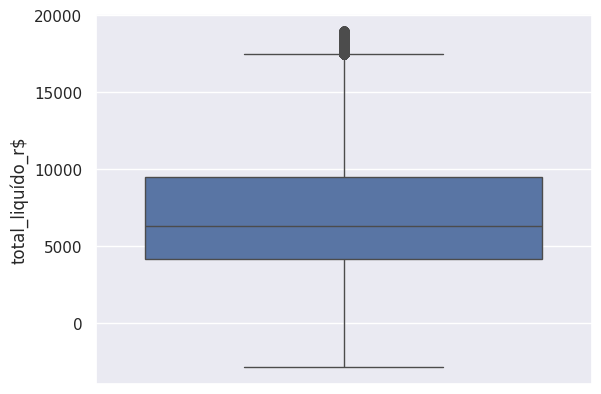

In [57]:
sns.boxplot(cleaned_df['total_liquído_r$'])

In [59]:
cleaned_df.to_csv('dataset_limpo_se.csv', index=False)

<Axes: >

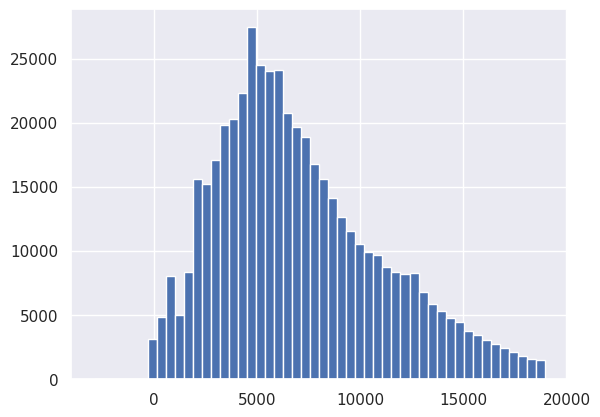

In [60]:
cleaned_df['total_liquído_r$'].hist(bins=50)

Bem diferente não?

# **6.2. Abordagem utilizando desvio padrão**

Explicação:
- Calcular Média e Desvio Padrão: A função remove_above_std_for_column calcula a média (mean) e o desvio padrão (std_dev) da coluna especificada.
- Definir Limite Superior: O limite superior é calculado para identificar valores que estão significativamente acima da média. Você pode ajustar esse fator se necessário.
- Definir Limite Inferior: O limite inferior é calculado para identificar valores que estão significativamente abaixo da média. Você pode ajustar esse fator se necessário.
- Filtrar o DataFrame: Filtra o DataFrame para salvar o extremos.
- Depois limpamos o dataset para remover os extremos.

**6.2 Abordagem utilizando desvio padrão - para outliers superiores a 3 desvio padrão.**

In [61]:
def filter_above_iqr_for_column(df, column_name):
    # Calcular média e desvio padrão
    mean = df[column_name].mean()
    std_dev = df[column_name].std()

    # Limite inferior
    upper_bound = mean + 3 * std_dev

    # Filtrar valores acima do limite superior
    column_outliers = df[df[column_name] > upper_bound]

    return column_outliers

# Filtrar valores superiores ao IQR para a coluna 'XXXX'
outliers_up = filter_above_iqr_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("Valores superiores ao IQR na coluna 'total_liquído_r$':")
print(outliers_up)

Valores superiores ao IQR na coluna 'total_liquído_r$':
                                 nome                          cargo  \
69                 ABEL JOSE DA SILVA  PROFESSOR DE ENSINO MED E TEC   
88               ABELARDO ALVES GOMES     DELEGADO POLICIA 1A CLASSE   
177             ABILIO EDISON MOREIRA  AUDITOR FISCAL DA RECEITA EST   
231      ABNER ALCANTARA SAMHA SANTOS   PROCURADOR DO ESTADO NIVEL I   
279             ABNER JOSE DE ALMEIDA  AUDITOR FISCAL DA RECEITA EST   
...                               ...                            ...   
504119         ZAINA MARIA GARBELLINI  PROFESSOR DE ENSINO MED E TEC   
504659                ZILDA LOPES MIO  PROFESSOR DE ENSINO MED E TEC   
504735               ZILLA OLIVA ROMA  PROCURADOR DO ESTADO NIVEL II   
504835  ZULANGE ODILA DA SILVA GRILLO  PROFESSOR DE ENSINO MED E TEC   
504909        ZULEIKA GONZALEZ ARAUJO     DELEGADO POLICIA 1A CLASSE   

                                 orgão  remuneração_do_mês  \
69      CTRO.EST.

**6.2 Abordagem utilizando desvio padrão - para outliers inferiores a 3 desvio padrão.**

In [62]:
def filter_below_std_for_column(df, column_name):
    # Calcular média e desvio padrão
    mean = df[column_name].mean()
    std_dev = df[column_name].std()

    # Limite inferior
    lower_bound = mean - 3 * std_dev

    # Filtrar valores abaixo do limite inferior
    column_outliers = df[df[column_name] < lower_bound]

    return column_outliers

# Filtrar valores abaixo do desvio padrão para a coluna 'MSRP'
outliers = filter_below_std_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("Valores abaixo do desvio padrão na coluna 'total_liquído_r$':")
print(outliers)

Valores abaixo do desvio padrão na coluna 'total_liquído_r$':
                            nome                   cargo  \
3233  ADMILSON SILVA DE CARVALHO  OFICIAL ADMINISTRATIVO   

                             orgão  remuneração_do_mês  férias_e_13º_salário  \
3233  SECRETARIA ADM.PENITENCIARIA                 0.0               -4979.7   

      pagamentos_eventuais  licença_prêmio_indenizada  \
3233             -14939.13                        0.0   

      abono_permanência_&_outras_indenizações  redutor_salarial  \
3233                                      0.0               0.0   

      total_liquído_r$ perc_remuneração_do_mês perc_férias_e_13º_salário  \
3233         -17162.96                    -0.0                  0.290142   

     perc_pagamentos_eventuais perc_licença_prêmio_indenizada  \
3233                  0.870429                           -0.0   

     perc_abono_permanência_&_outras_indenizações perc_redutor_salarial  
3233                                         -0.

**6.2. Removendo outliers utilizando o Desvio Padrão**

Uma abordagem simples é considerar dados que estão a mais de 2 ou 3 desvios padrões da média como outliers.

**Removendo Ouliers maiores do que 3 desvio padrão**

In [63]:
def remove_above_std_for_column(df, column_name):
    # Calcular média e desvio padrão
    mean = df[column_name].mean()
    std_dev = df[column_name].std()

    # Limite superior
    upper_bound = mean + 3 * std_dev

    # Filtrar valores abaixo do limite superior
    filtered_df = df[df[column_name] <= upper_bound]

    return filtered_df

# Remover valores acima do desvio padrão para a coluna 'MSRP'
cleaned_df_sd = remove_above_std_for_column(df, 'total_liquído_r$')

# Exibir os resultados
print("DataFrame após remover os valores acima do desvio padrão na coluna 'total_liquído_r$':")
print(cleaned_df_sd)

DataFrame após remover os valores acima do desvio padrão na coluna 'total_liquído_r$':
                                  nome                          cargo  \
0         A UCENA ROSA REGINALDO SILVA                     ESTAGIARIO   
1                AALAN DA SILVA ARAUJO                          SD PM   
2           AARAN ESTEVAO LIMA BARBOSA                       CAP   PM   
3              AARAO HENRIQUE OLIVEIRA               POLICIAL PENAL I   
4              AARAO HENRIQUE OLIVEIRA                OUTROS VINCULOS   
...                                ...                            ...   
504951  ZUMARLI APARECIDA MENEGON NUCI         OFICIAL ADMINISTRATIVO   
504952          ZUMELICE FERREIRA LIMA  PROF ENSINO FUNDAMENTAL/MEDIO   
504953       ZUNAIDE DOS SANTOS ARAUJO    PROFESSOR EDUCACAO BASICA I   
504954         ZUPELLI CROZARIOL FILHO                       CABO  PM   
504955            ZURMA DE SOUZA PINTO  PROF ENSINO FUNDAMENTAL/MEDIO   

                                 org

**Removendo Ouliers menores do que 3 desvio padrão**

In [64]:
def remove_below_std_for_column(df, column_name):
    # Calcular média e desvio padrão
    mean = df[column_name].mean()
    std_dev = df[column_name].std()

    # Limite inferior
    lower_bound = mean - 3 * std_dev

    # Filtrar valores acima do limite inferior
    filtered_df = df[df[column_name] >= lower_bound]

    return filtered_df

# Remover valores abaixo de 3 desvios padrão para a coluna 'MSRP'
cleaned_df_sd = remove_below_std_for_column(cleaned_df_sd, 'total_liquído_r$')

# Exibir os resultados
print("DataFrame após remover os valores abaixo de 3 desvios padrão na coluna 'total_liquído_r$':")
print(cleaned_df_sd)

DataFrame após remover os valores abaixo de 3 desvios padrão na coluna 'total_liquído_r$':
                                  nome                          cargo  \
0         A UCENA ROSA REGINALDO SILVA                     ESTAGIARIO   
1                AALAN DA SILVA ARAUJO                          SD PM   
2           AARAN ESTEVAO LIMA BARBOSA                       CAP   PM   
3              AARAO HENRIQUE OLIVEIRA               POLICIAL PENAL I   
4              AARAO HENRIQUE OLIVEIRA                OUTROS VINCULOS   
...                                ...                            ...   
504951  ZUMARLI APARECIDA MENEGON NUCI         OFICIAL ADMINISTRATIVO   
504952          ZUMELICE FERREIRA LIMA  PROF ENSINO FUNDAMENTAL/MEDIO   
504953       ZUNAIDE DOS SANTOS ARAUJO    PROFESSOR EDUCACAO BASICA I   
504954         ZUPELLI CROZARIOL FILHO                       CABO  PM   
504955            ZURMA DE SOUZA PINTO  PROF ENSINO FUNDAMENTAL/MEDIO   

                                

**Tarefa:**
- Compare os resutlados da abordagem IQR, desvio padrão e SVM para uma variável, refazendo a análise exploratório após a remoção de outliers.**

<Axes: ylabel='total_liquído_r$'>

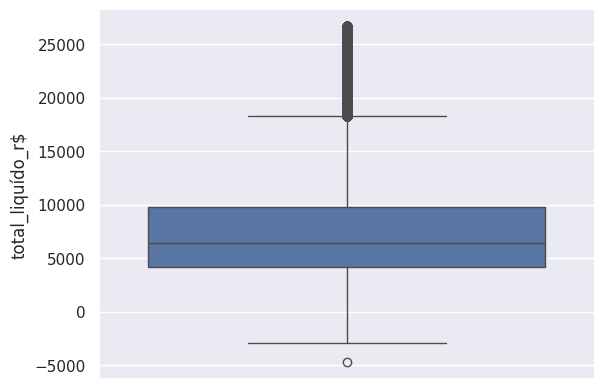

In [65]:
sns.boxplot(cleaned_df_sd['total_liquído_r$'])

<Axes: >

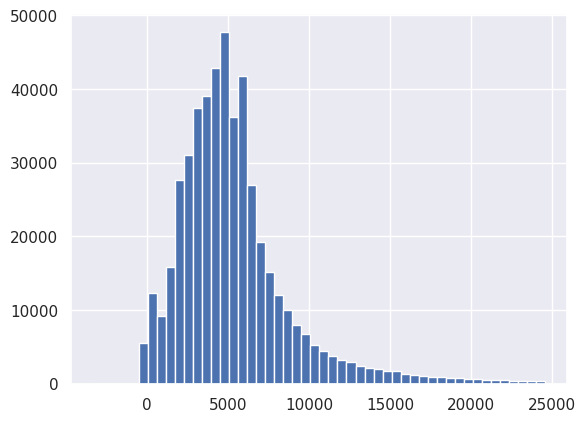

In [ ]:
cleaned_df_sd['total_liquído_r$'].hist(bins=50)

**Resumo**

Escolher o método apropriado depende do contexto e dos requisitos da análise. O método do desvio padrão é simples e rápido, enquanto o IQR é mais robusto e frequentemente usado para dados não normalmente distribuídos.

Os Boxplots são úteis para visualização da distribuição de valores em relação a extremos e histogramas permite verificar como ocorre a distribuição dos valores em termos de frequência.

O que acha?

Viu como só o uso da EDA já permite conhecer muito sobre o dataset?

Acha que após a análise você tomaria decisões diferentes de como trabalhar esses dados?

Na aula que vem amos ver o que acontece a partir disso.